### 228. Kullback-Leibler divergence between channel distributions

Kullback–Leibler divergence is $D_{KL}(P\|Q)=\sum_ip_i\ln(p_i/q_i)$. A common support and positive pseudocount are used so finite histograms do not create undefined logarithms.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


KL(ch0||ch1)= 0.02885226489622034


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


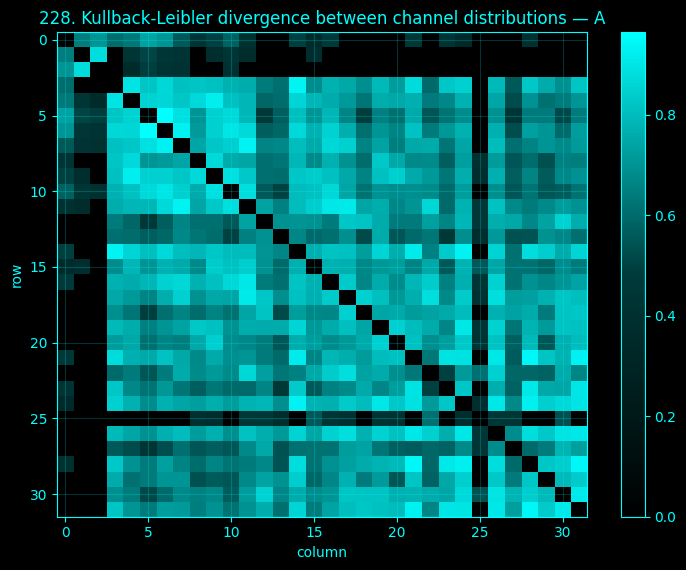

In [204]:
# =======================================================
# 228. Kullback-Leibler divergence between channel distributions
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Kullback–Leibler divergence is $D_{KL}(P\|Q)=\sum_ip_i\ln(p_i/q_i)$. A common support
# and positive pseudocount are used so finite histograms do not create undefined logarithms.
# =======================================================
def _entropy_method_228():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    n = min(8, X.shape[1])
    P = []
    edges = np.linspace(np.min(X[:, :n]), np.max(X[:, :n]), 33)
    for j in range(n):
        P.append(_safe_prob(np.histogram(X[:, j], edges)[0] + 0.5))
    p, q = (P[0], P[1])
    _ent_print_args = ['KL(ch0||ch1)=', _kl(p, q)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_228()
_ent_auto_plot(228, 'Kullback-Leibler divergence between channel distributions', _ent_method_ns, ['X', 'y', 'powv', 'n', 'P', 'edges', 'j', '_ent_print_args', 'G', 'W', 'A', 'p', 'q'])


### 229. Symmetric KL divergence

Symmetric KL is $D_{SKL}(P,Q)=\tfrac12[D_{KL}(P\|Q)+D_{KL}(Q\|P)]$. Unlike JSD it is not bounded.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


symmetric KL= 0.02866407043861928


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


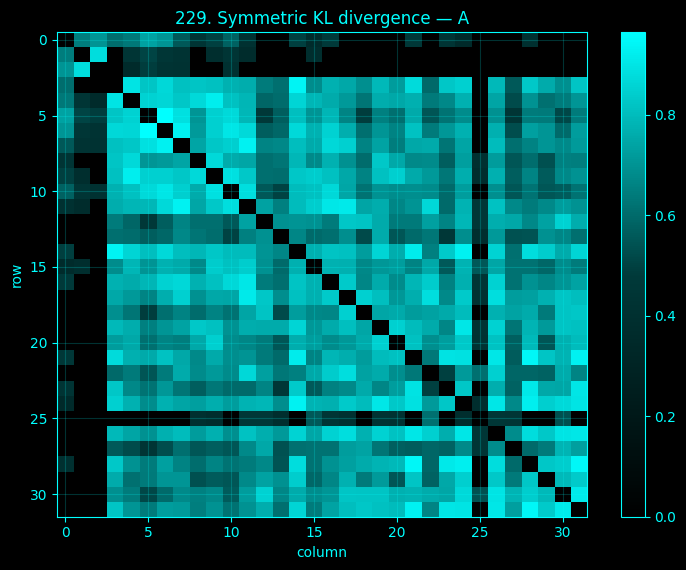

In [205]:
# =======================================================
# 229. Symmetric KL divergence
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Symmetric KL is $D_{SKL}(P,Q)=\tfrac12[D_{KL}(P\|Q)+D_{KL}(Q\|P)]$. Unlike JSD it is
# not bounded.
# =======================================================
def _entropy_method_229():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    n = min(8, X.shape[1])
    P = []
    edges = np.linspace(np.min(X[:, :n]), np.max(X[:, :n]), 33)
    for j in range(n):
        P.append(_safe_prob(np.histogram(X[:, j], edges)[0] + 0.5))
    p, q = (P[0], P[1])
    _ent_print_args = ['symmetric KL=', 0.5 * (_kl(p, q) + _kl(q, p))]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_229()
_ent_auto_plot(229, 'Symmetric KL divergence', _ent_method_ns, ['X', 'y', 'powv', 'n', 'P', 'edges', 'j', '_ent_print_args', 'G', 'W', 'A', 'p', 'q'])


### 230. Rényi divergence

Rényi divergence of order $\alpha\ne1$ is $D_\alpha(P\|Q)=\frac{1}{\alpha-1}\ln\sum_i p_i^\alpha q_i^{1-\alpha}$. The cell uses $\alpha=2$.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Renyi divergence alpha=2= 0.06719267785379417


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


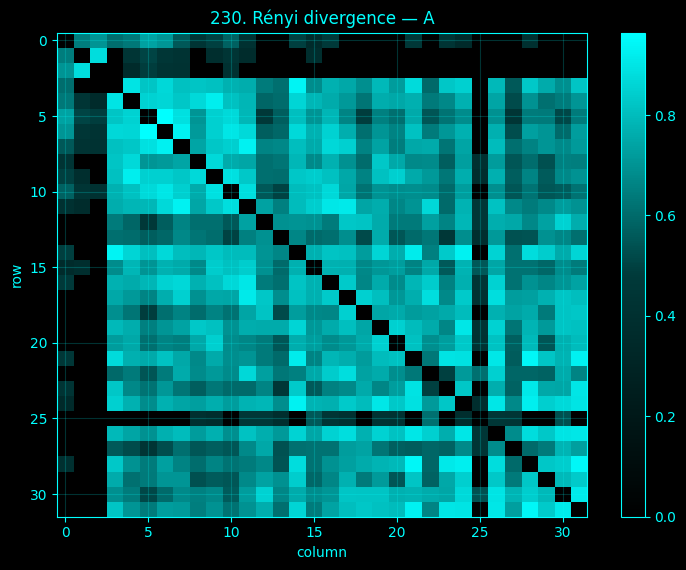

In [206]:
# =======================================================
# 230. Rényi divergence
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Rényi divergence of order $\alpha\ne1$ is $D_\alpha(P\|Q)=\frac{1}{\alpha-1}\ln\sum_i
# p_i^\alpha q_i^{1-\alpha}$. The cell uses $\alpha=2$.
# =======================================================
def _entropy_method_230():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    n = min(8, X.shape[1])
    P = []
    edges = np.linspace(np.min(X[:, :n]), np.max(X[:, :n]), 33)
    for j in range(n):
        P.append(_safe_prob(np.histogram(X[:, j], edges)[0] + 0.5))
    p, q = (P[0], P[1])
    _ent_print_args = ['Renyi divergence alpha=2=', _renyi_div(p, q, 2)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_230()
_ent_auto_plot(230, 'Rényi divergence', _ent_method_ns, ['X', 'y', 'powv', 'n', 'P', 'edges', 'j', '_ent_print_args', 'G', 'W', 'A', 'p', 'q'])


### 231. Tsallis divergence

Tsallis relative entropy of order $q\ne1$ is $D_q(P\|Q)=[\sum_i p_i^q q_i^{1-q}-1]/(q-1)$ under the convention used here. The cell uses order 2.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Tsallis divergence q=2= 0.06950152758134798


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


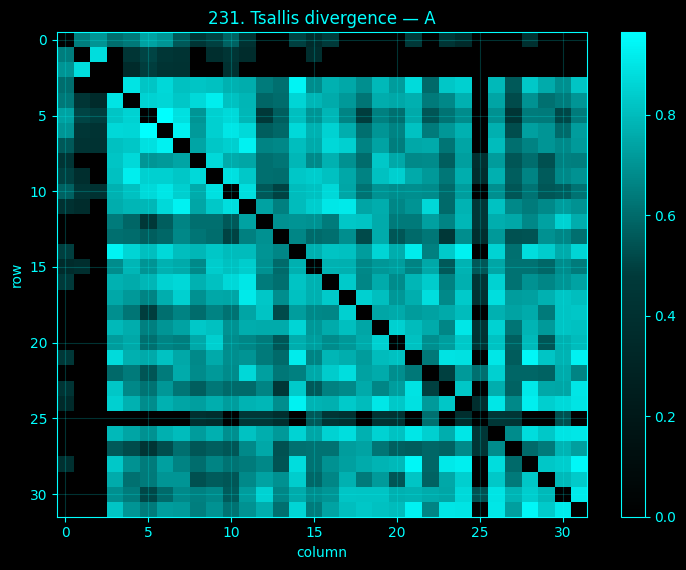

In [207]:
# =======================================================
# 231. Tsallis divergence
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Tsallis relative entropy of order $q\ne1$ is $D_q(P\|Q)=[\sum_i p_i^q
# q_i^{1-q}-1]/(q-1)$ under the convention used here. The cell uses order 2.
# =======================================================
def _entropy_method_231():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    n = min(8, X.shape[1])
    P = []
    edges = np.linspace(np.min(X[:, :n]), np.max(X[:, :n]), 33)
    for j in range(n):
        P.append(_safe_prob(np.histogram(X[:, j], edges)[0] + 0.5))
    p, q = (P[0], P[1])
    _ent_print_args = ['Tsallis divergence q=2=', _tsallis_div(p, q, 2)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_231()
_ent_auto_plot(231, 'Tsallis divergence', _ent_method_ns, ['X', 'y', 'powv', 'n', 'P', 'edges', 'j', '_ent_print_args', 'G', 'W', 'A', 'p', 'q'])


### 232. Earth-mover entropy-style distribution distance

The one-dimensional Earth-mover/Wasserstein-1 distance is $W_1(P,Q)=\int_0^1|F_P^{-1}(u)-F_Q^{-1}(u)|du$. It is a distribution distance, not an entropy; the original catalogue’s “entropy-style” wording is retained but clarified.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Wasserstein distance between persistence diagrams also matches topological features, but it aggregates matching costs rather than keeping only the largest one. The order parameter determines how strongly large discrepancies are emphasized. As with the bottleneck distance, matching to the diagonal represents treating a short-lived feature in one diagram as absent in the other.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


1-D Wasserstein-1 / Earth-mover distribution distance= 0.06858333320391326


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


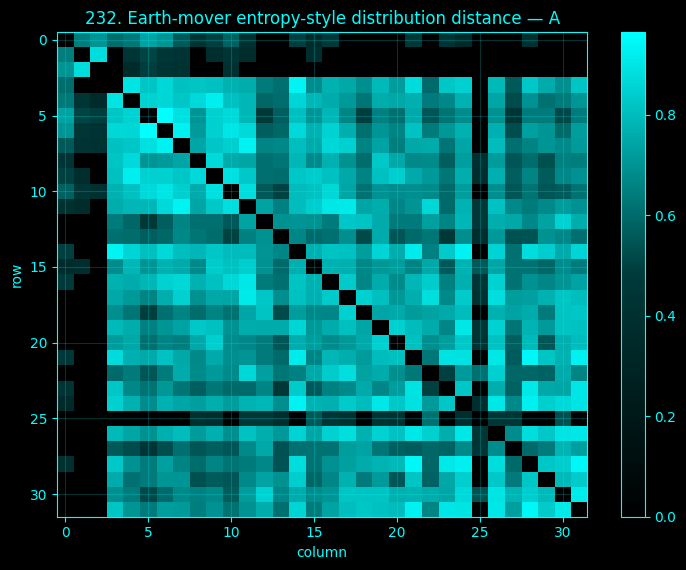

In [208]:
# =======================================================
# 232. Earth-mover entropy-style distribution distance
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: The one-dimensional Earth-mover/Wasserstein-1 distance is
# $W_1(P,Q)=\int_0^1|F_P^{-1}(u)-F_Q^{-1}(u)|du$. It is a distribution distance, not an entropy; the
# original catalogue’s “entropy-style” wording is retained but clarified.
# =======================================================
def _entropy_method_232():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    n = min(8, X.shape[1])
    P = []
    edges = np.linspace(np.min(X[:, :n]), np.max(X[:, :n]), 33)
    for j in range(n):
        P.append(_safe_prob(np.histogram(X[:, j], edges)[0] + 0.5))
    p, q = (P[0], P[1])
    _ent_print_args = ['1-D Wasserstein-1 / Earth-mover distribution distance=', stats.wasserstein_distance(X[:, 0], X[:, 1])]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_232()
_ent_auto_plot(232, 'Earth-mover entropy-style distribution distance', _ent_method_ns, ['X', 'y', 'powv', 'n', 'P', 'edges', 'j', '_ent_print_args', 'G', 'W', 'A', 'p', 'q'])


### 233. Entropy-based channel separability

Channel separability is summarized as each channel’s mean Jensen–Shannon divergence to the other channels. Larger values indicate a more distributionally distinctive amplitude law; this is a divergence-based ranking, not classification accuracy.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


,channel,mean_JSD_separability
2,Fp2,0.055352
1,Fpz,0.029694
0,Fp1,0.029374
3,F7,0.028562
7,F8,0.022420
4,F3,0.021947
6,F4,0.021738
5,Fz,0.018336


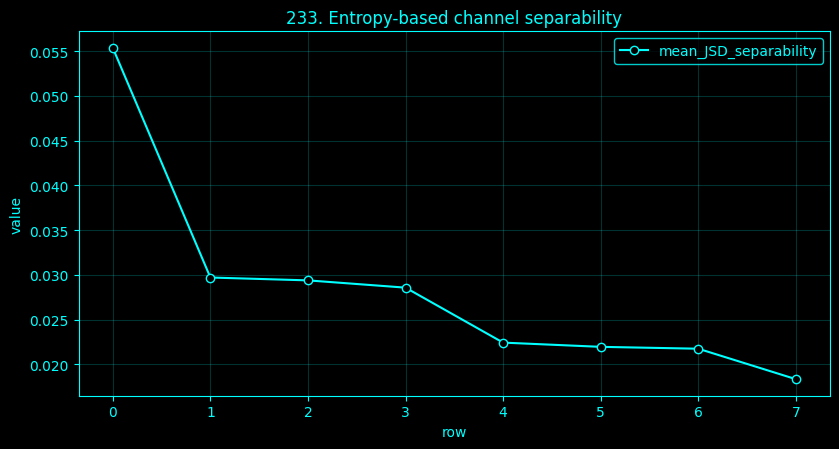

In [209]:
# =======================================================
# 233. Entropy-based channel separability
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Channel separability is summarized as each channel’s mean Jensen–Shannon divergence to
# the other channels. Larger values indicate a more distributionally distinctive amplitude law; this
# is a divergence-based ranking, not classification accuracy.
# =======================================================
def _entropy_method_233():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    n = min(8, X.shape[1])
    P = []
    edges = np.linspace(np.min(X[:, :n]), np.max(X[:, :n]), 33)
    for j in range(n):
        P.append(_safe_prob(np.histogram(X[:, j], edges)[0] + 0.5))
    p, q = (P[0], P[1])
    M = np.zeros((n, n))
    for a in range(n):
        for b in range(n):
            M[a, b] = _jsd(P[a], P[b])
    score = (M.sum(1) - np.diag(M)) / (n - 1)
    _ent_display_result = pd.DataFrame({'channel': _ent_names[:n], 'mean_JSD_separability': score}).sort_values('mean_JSD_separability', ascending=False)
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_233()
_ent_auto_plot(233, 'Entropy-based channel separability', _ent_method_ns, ['X', 'y', 'powv', 'n', 'P', 'edges', 'j', 'M', 'a', 'score', '_ent_display_result', 'G', 'W', 'A', 'p', 'q', 'b'])


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and role — surrogate inference and entropy-feature helpers for methods 234–255</h3>
<p>This cell defines null-model, bootstrap, multiple-testing, and entropy-feature utilities. Surrogate p-values use \(p=(1+\#\{T_b\ge T_{obs}\})/(B+1)\) for the stated one-sided statistic, while BH-FDR orders p-values and controls the selected false-discovery rate. Shuffle, Fourier-phase, IAAFT, and colored-noise nulls are kept separate because they preserve different signal properties.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> When many hypotheses are tested, some small p-values occur by chance. Benjamini-Hochberg false-discovery-rate control ranks the p-values and chooses a threshold designed to limit the expected fraction of false discoveries among the results called significant. FDR control is less strict than controlling the probability of any false positive, which gives it more power in large exploratory analyses. The correction should be applied to a clearly defined family of related tests.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted. Statistical significance should be read relative to the stated null model and testing procedure; it is strongest when accompanied by an effect size, uncertainty estimate, and correction for the number of comparisons when many tests are run.</p></div>


In [210]:
# =======================================================
# Shared primitives only; numbered cells below contain the method-specific mathematics.
# SHARED NUMERICAL PRIMITIVES — methods 234–255
# Surrogate inference and entropy feature/topography/state analyses.
# =======================================================
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import cdist

def _phase_surrogate(y,rng=None):
    rng=np.random.default_rng() if rng is None else rng;y=np.asarray(y,float);Y=np.fft.rfft(y);ph=rng.uniform(0,2*np.pi,len(Y));ph[0]=0
    if len(y)%2==0:ph[-1]=0
    Z=np.abs(Y)*np.exp(1j*ph);return np.fft.irfft(Z,n=len(y))

def _iaaft(y,rng=None,iters=None):
    rng=np.random.default_rng() if rng is None else rng;y=np.asarray(y,float);target=np.abs(np.fft.rfft(y));sorted_y=np.sort(y);z=rng.permutation(y);iters=int(iters or {'full':80,'balanced':50,'fast':30,'ultra':15}[FAST_OPTION])
    for _ in range(iters):
        Z=np.fft.rfft(z);z=np.fft.irfft(target*np.exp(1j*np.angle(Z)),n=len(y));r=np.argsort(z);zz=np.empty_like(z);zz[r]=sorted_y;z=zz
    return z

def _psd_slope(y):
    f,P=signal.welch(y,fs=_ent_fs,nperseg=min(len(y),max(64,int(2*_ent_fs))));m=(f>max(.5,1/len(y)))&(f<min(.4*_ent_fs,45))&(P>0)
    if m.sum()<4:return 0.0
    return float(-np.polyfit(np.log(f[m]),np.log(P[m]),1)[0])

def _colored_noise_like(y,rng=None):
    rng=np.random.default_rng() if rng is None else rng;y=np.asarray(y,float);n=len(y);beta=np.clip(_psd_slope(y),-2.5,3.5);f=np.fft.rfftfreq(n,d=1/_ent_fs);amp=np.ones_like(f);amp[1:]=np.maximum(f[1:],1/n)**(-beta/2);ph=rng.uniform(0,2*np.pi,len(f));ph[0]=0
    if n%2==0:ph[-1]=0
    z=np.fft.irfft(amp*np.exp(1j*ph),n=n);z=(z-z.mean())/(z.std()+ENT_EPS)*np.std(y)+np.mean(y);return z,beta

def _emp_p(obs,null,two=False):
    null=np.asarray(null,float);null=null[np.isfinite(null)]
    if not len(null):return np.nan
    if two:
        c=np.mean(null);return float((1+np.sum(np.abs(null-c)>=abs(obs-c)))/(len(null)+1))
    return float((1+np.sum(null>=obs))/(len(null)+1))

def _bh(p):
    p=np.asarray(p,float);n=len(p);order=np.argsort(p);q=np.empty(n);prev=1.
    for rank,idx in reversed(list(enumerate(order,1))):prev=min(prev,p[idx]*n/rank);q[idx]=prev
    return np.clip(q,0,1)

def _spectral_H(y):
    f,P=signal.welch(np.asarray(y,float),fs=_ent_fs,nperseg=min(len(y),max(64,int(2*_ent_fs))));p=_safe_prob(P);return _H(p)/np.log(max(2,len(p)))

def _channel_entropy_features(maxch=None):
    n=int(maxch or _ent_x.shape[1]);rows=[]
    for j in range(n):
        z=_ent_x[:,j];rows.append([_H(_hist_p(z,24))/np.log(24),_sampen(z),_perm_entropy(z),_disp_entropy(z),_spectral_H(z),_lz_norm(_symbolize(z,4),4)])
    F=np.asarray(rows,float);F[~np.isfinite(F)]=np.nan
    med=np.nanmedian(F,axis=0);inds=np.where(~np.isfinite(F));F[inds]=np.take(med,inds[1]);return F

def _zcols(F):
    F=np.asarray(F,float);return (F-F.mean(0,keepdims=True))/(F.std(0,keepdims=True)+ENT_EPS)

def _window_entropy_features():
    W=max(100,int(3*_ent_fs));starts=np.linspace(0,max(0,len(_ent_y)-W),_ENT_SPEED['windows']).astype(int);rows=[]
    for s in starts:
        z=_ent_y[s:s+W];top=_H(_safe_prob(np.var(_ent_x[s:s+W],axis=0)));rows.append([_perm_entropy(z),_disp_entropy(z),_spectral_H(z),top])
    return starts,np.asarray(rows,float)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Execution router — entropy methods 234–255</h3>
<p>This dispatcher applies the requested surrogate/inference or entropy-fingerprint/state analysis with the common null-model and bootstrap machinery. Runtime mode changes the number of replicates or sampled windows, not the test statistic.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A p-value is the probability, under the specified null model, of obtaining a statistic at least as extreme as the observed one. It is not the probability that the null hypothesis is true and it does not measure effect size. A useful interpretation therefore combines the p-value with the observed magnitude, uncertainty, multiple-testing correction when relevant, and the assumptions of the null model.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary. Statistical significance should be read relative to the stated null model and testing procedure; it is strongest when accompanied by an effect size, uncertainty estimate, and correction for the number of comparisons when many tests are run.</p></div>


**Explicit implementation note — methods 234–255.**  
The catalogue dispatcher has been removed. Each numbered method below now contains its own executable mathematics in that method's code cell. Only reusable numerical primitives and the shared black/cyan plotting utilities remain centralized.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


### 234. Entropy surrogate testing

A surrogate test compares an observed entropy statistic $T(x)$ with statistics from null series that preserve specified properties. This cell reports empirical two-sided p-values against shuffle, Fourier-phase, and IAAFT nulls; the null family is part of the hypothesis and is never interchangeable.

**Implementation.** The existing EEG segment and plotting conventions are reused. Expensive null ensembles and window counts obey `full / balanced / fast / ultra`; `full` retains the largest budgets.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A surrogate test creates artificial signals that preserve selected simple properties of the original data while deliberately removing the structure being tested. IAAFT surrogates approximately preserve the amplitude distribution and power spectrum, and therefore much of the linear autocorrelation structure, while randomizing nonlinear temporal organization. The observed statistic is then compared with the surrogate distribution. A small surrogate-based p-value means the observed statistic is unusual under that null model; it does not by itself identify the biological mechanism responsible for the difference.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


,null,observed_PE,null_mean,null_sd,two_sided_empirical_p
0,shuffle,0.934594,0.998516,0.000699,0.166667
1,phase,0.934594,0.958197,0.004977,0.166667
2,IAAFT,0.934594,0.924061,0.004914,0.166667


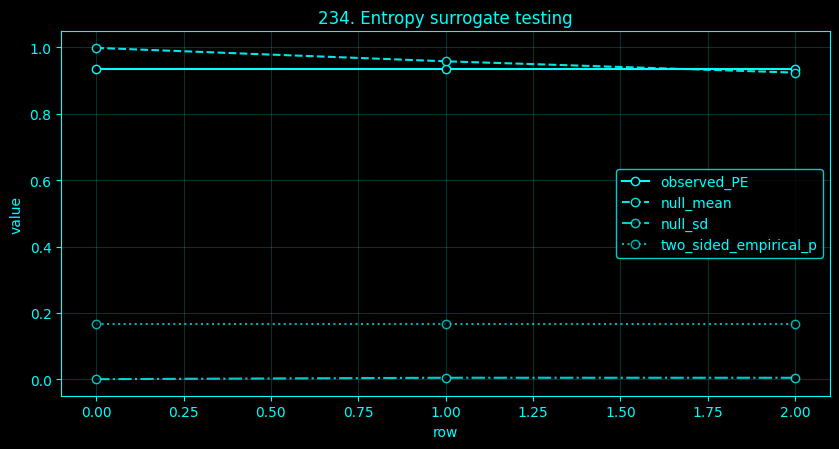

In [211]:
# =======================================================
# 234. Entropy surrogate testing
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: A surrogate test compares an observed entropy statistic $T(x)$ with statistics from
# null series that preserve specified properties. This cell reports empirical two-sided p-values
# against shuffle, Fourier-phase, and IAAFT nulls; the null family is part of the hypothesis and is
# never interchangeable.
# =======================================================
def _entropy_method_234():
    y = _ent_y
    X = _ent_x
    rng = np.random.default_rng(1000 + 234)
    B = _ENT_SPEED['sur']
    obs = _perm_entropy(y)
    nulls = {}
    nulls['shuffle'] = [_perm_entropy(rng.permutation(y)) for _ in range(B)]
    nulls['phase'] = [_perm_entropy(_phase_surrogate(y, rng)) for _ in range(B)]
    nulls['IAAFT'] = [_perm_entropy(_iaaft(y, rng)) for _ in range(B)]
    rows = [[k, obs, float(np.mean(v)), float(np.std(v)), _emp_p(obs, v, True)] for k, v in nulls.items()]
    _ent_display_result = pd.DataFrame(rows, columns=['null', 'observed_PE', 'null_mean', 'null_sd', 'two_sided_empirical_p'])
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_234()
_ent_auto_plot(234, 'Entropy surrogate testing', _ent_method_ns, ['y', 'X', 'rng', 'B', 'obs', 'nulls', 'rows', '_ent_display_result', '_', 'k', 'v'])


### 235. Shuffle-surrogate entropy testing

Random shuffling preserves the sample-value multiset exactly but destroys temporal order. Entropy under shuffled surrogates therefore tests whether temporal dependence contributes beyond the one-point amplitude distribution.

**Implementation.** The existing EEG segment and plotting conventions are reused. Expensive null ensembles and window counts obey `full / balanced / fast / ultra`; `full` retains the largest budgets.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A surrogate test creates artificial signals that preserve selected simple properties of the original data while deliberately removing the structure being tested. IAAFT surrogates approximately preserve the amplitude distribution and power spectrum, and therefore much of the linear autocorrelation structure, while randomizing nonlinear temporal organization. The observed statistic is then compared with the surrogate distribution. A small surrogate-based p-value means the observed statistic is unusual under that null model; it does not by itself identify the biological mechanism responsible for the difference.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


{'observed_PE': 0.9345943584211771, 'null_mean': 0.9991365562675595, 'null_sd': 0.00043856544069884707, 'two_sided_p': 0.16666666666666666, 'colored_beta': None}


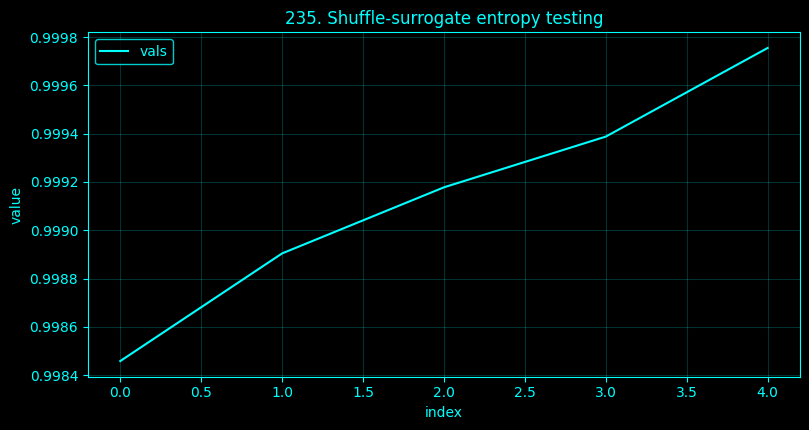

In [212]:
# =======================================================
# 235. Shuffle-surrogate entropy testing
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Random shuffling preserves the sample-value multiset exactly but destroys temporal
# order. Entropy under shuffled surrogates therefore tests whether temporal dependence contributes
# beyond the one-point amplitude distribution.
# =======================================================
def _entropy_method_235():
    y = _ent_y
    X = _ent_x
    rng = np.random.default_rng(1000 + 235)
    B = _ENT_SPEED['sur']
    obs = _perm_entropy(y)
    vals = []
    beta = np.nan
    for _ in range(B):
        z = rng.permutation(y)
        vals.append(_perm_entropy(z))
    _ent_print_args = [{'observed_PE': obs, 'null_mean': float(np.mean(vals)), 'null_sd': float(np.std(vals)), 'two_sided_p': _emp_p(obs, vals, True), 'colored_beta': None}]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_235()
_ent_auto_plot(235, 'Shuffle-surrogate entropy testing', _ent_method_ns, ['y', 'X', 'rng', 'B', 'obs', 'vals', 'beta', '_', '_ent_print_args', 'z'])


### 236. Phase-randomized surrogate entropy testing

Fourier phase randomization keeps each Fourier magnitude $|X(f)|$ and therefore the discrete periodogram while randomizing phases subject to real-signal conjugacy. It does not in general preserve the original amplitude distribution.

**Implementation.** The existing EEG segment and plotting conventions are reused. Expensive null ensembles and window counts obey `full / balanced / fast / ultra`; `full` retains the largest budgets.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A surrogate test creates artificial signals that preserve selected simple properties of the original data while deliberately removing the structure being tested. IAAFT surrogates approximately preserve the amplitude distribution and power spectrum, and therefore much of the linear autocorrelation structure, while randomizing nonlinear temporal organization. The observed statistic is then compared with the surrogate distribution. A small surrogate-based p-value means the observed statistic is unusual under that null model; it does not by itself identify the biological mechanism responsible for the difference.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


{'observed_PE': 0.9345943584211771, 'null_mean': 0.958962255883514, 'null_sd': 0.004379657538317223, 'two_sided_p': 0.16666666666666666, 'colored_beta': None}


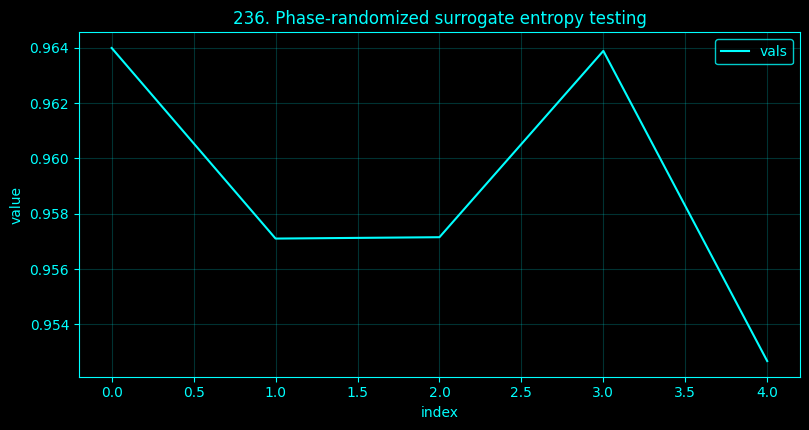

In [213]:
# =======================================================
# 236. Phase-randomized surrogate entropy testing
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Fourier phase randomization keeps each Fourier magnitude $|X(f)|$ and therefore the
# discrete periodogram while randomizing phases subject to real-signal conjugacy. It does not in
# general preserve the original amplitude distribution.
# =======================================================
def _entropy_method_236():
    y = _ent_y
    X = _ent_x
    rng = np.random.default_rng(1000 + 236)
    B = _ENT_SPEED['sur']
    obs = _perm_entropy(y)
    vals = []
    beta = np.nan
    for _ in range(B):
        z = _phase_surrogate(y, rng)
        vals.append(_perm_entropy(z))
    _ent_print_args = [{'observed_PE': obs, 'null_mean': float(np.mean(vals)), 'null_sd': float(np.std(vals)), 'two_sided_p': _emp_p(obs, vals, True), 'colored_beta': None}]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_236()
_ent_auto_plot(236, 'Phase-randomized surrogate entropy testing', _ent_method_ns, ['y', 'X', 'rng', 'B', 'obs', 'vals', 'beta', '_', '_ent_print_args', 'z'])


### 237. IAAFT-surrogate entropy testing

IAAFT alternates a Fourier-magnitude projection with rank remapping to the original sorted amplitudes. It approximately preserves the power spectrum while preserving the empirical amplitude distribution exactly after each rank-remapping step.

**Implementation.** The existing EEG segment and plotting conventions are reused. Expensive null ensembles and window counts obey `full / balanced / fast / ultra`; `full` retains the largest budgets.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A surrogate test creates artificial signals that preserve selected simple properties of the original data while deliberately removing the structure being tested. IAAFT surrogates approximately preserve the amplitude distribution and power spectrum, and therefore much of the linear autocorrelation structure, while randomizing nonlinear temporal organization. The observed statistic is then compared with the surrogate distribution. A small surrogate-based p-value means the observed statistic is unusual under that null model; it does not by itself identify the biological mechanism responsible for the difference.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


{'observed_PE': 0.9345943584211771, 'null_mean': 0.9278156053119965, 'null_sd': 0.005219237434478304, 'two_sided_p': 0.3333333333333333, 'colored_beta': None}


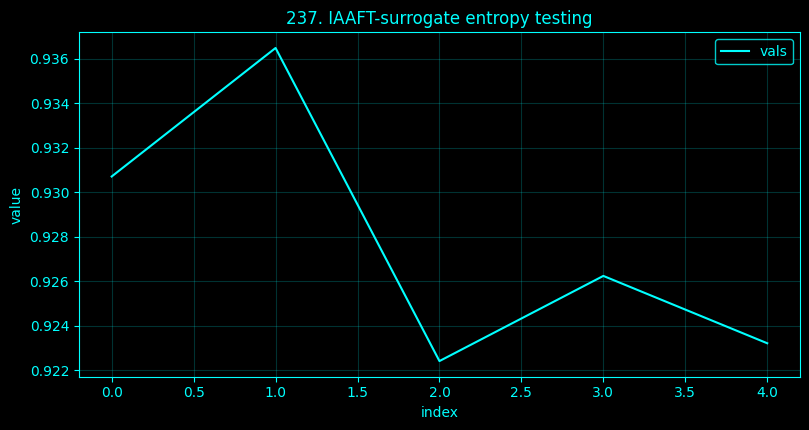

In [214]:
# =======================================================
# 237. IAAFT-surrogate entropy testing
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: IAAFT alternates a Fourier-magnitude projection with rank remapping to the original
# sorted amplitudes. It approximately preserves the power spectrum while preserving the empirical
# amplitude distribution exactly after each rank-remapping step.
# =======================================================
def _entropy_method_237():
    y = _ent_y
    X = _ent_x
    rng = np.random.default_rng(1000 + 237)
    B = _ENT_SPEED['sur']
    obs = _perm_entropy(y)
    vals = []
    beta = np.nan
    for _ in range(B):
        z = _iaaft(y, rng)
        vals.append(_perm_entropy(z))
    _ent_print_args = [{'observed_PE': obs, 'null_mean': float(np.mean(vals)), 'null_sd': float(np.std(vals)), 'two_sided_p': _emp_p(obs, vals, True), 'colored_beta': None}]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_237()
_ent_auto_plot(237, 'IAAFT-surrogate entropy testing', _ent_method_ns, ['y', 'X', 'rng', 'B', 'obs', 'vals', 'beta', '_', '_ent_print_args', 'z'])


### 238. Colored-noise surrogate entropy testing

Colored-noise surrogates are generated with spectral amplitude $|X(f)|\propto f^{-\beta/2}$ after fitting the target PSD slope $P(f)\propto f^{-\beta}$. They preserve the fitted spectral color and variance, not the exact periodogram or amplitude distribution.

**Implementation.** The existing EEG segment and plotting conventions are reused. Expensive null ensembles and window counts obey `full / balanced / fast / ultra`; `full` retains the largest budgets.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A surrogate test creates artificial signals that preserve selected simple properties of the original data while deliberately removing the structure being tested. IAAFT surrogates approximately preserve the amplitude distribution and power spectrum, and therefore much of the linear autocorrelation structure, while randomizing nonlinear temporal organization. The observed statistic is then compared with the surrogate distribution. A small surrogate-based p-value means the observed statistic is unusual under that null model; it does not by itself identify the biological mechanism responsible for the difference.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The proportionality symbol means the two quantities are expected to follow the same scaling law up to a multiplicative constant.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


{'observed_PE': 0.9345943584211771, 'null_mean': 0.926918965900595, 'null_sd': 0.004457867545023759, 'two_sided_p': 0.16666666666666666, 'colored_beta': np.float64(2.103947983350609)}


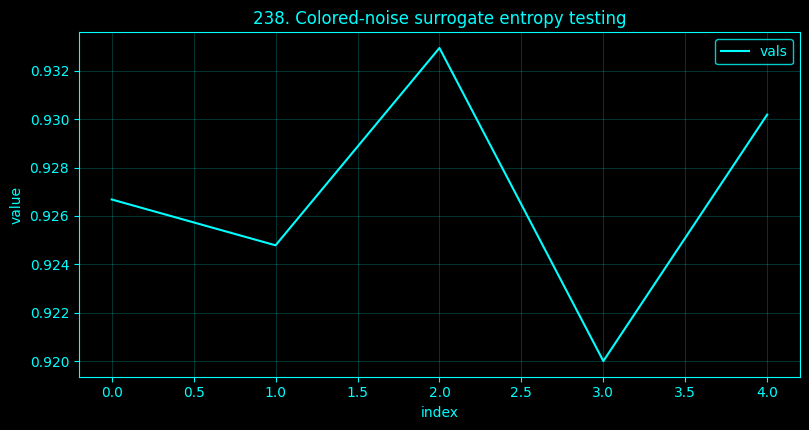

In [215]:
# =======================================================
# 238. Colored-noise surrogate entropy testing
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Colored-noise surrogates are generated with spectral amplitude $|X(f)|\propto
# f^{-\beta/2}$ after fitting the target PSD slope $P(f)\propto f^{-\beta}$. They preserve the fitted
# spectral color and variance, not the exact periodogram or amplitude distribution.
# =======================================================
def _entropy_method_238():
    y = _ent_y
    X = _ent_x
    rng = np.random.default_rng(1000 + 238)
    B = _ENT_SPEED['sur']
    obs = _perm_entropy(y)
    vals = []
    beta = np.nan
    for _ in range(B):
        z, beta = _colored_noise_like(y, rng)
        vals.append(_perm_entropy(z))
    _ent_print_args = [{'observed_PE': obs, 'null_mean': float(np.mean(vals)), 'null_sd': float(np.std(vals)), 'two_sided_p': _emp_p(obs, vals, True), 'colored_beta': beta}]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_238()
_ent_auto_plot(238, 'Colored-noise surrogate entropy testing', _ent_method_ns, ['y', 'X', 'rng', 'B', 'obs', 'vals', 'beta', '_', '_ent_print_args', 'z'])


### 239. Bootstrap confidence intervals for entropy metrics

A moving-block bootstrap resamples contiguous blocks so short-range temporal dependence is retained approximately. The 2.5% and 97.5% bootstrap quantiles form a nonparametric 95% interval for permutation entropy.

**Implementation.** The existing EEG segment and plotting conventions are reused. Expensive null ensembles and window counts obey `full / balanced / fast / ultra`; `full` retains the largest budgets.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Permutation entropy replaces the exact amplitudes of short windows by their rank order. For example, a three-sample window is represented by which sample is smallest, middle, and largest. The probability distribution of these ordinal patterns is then summarized by Shannon entropy. This makes the measure relatively robust to monotonic amplitude transformations, while still being sensitive to temporal ordering. The embedding order and delay determine which time scales and pattern lengths are emphasized.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Permutation entropy bootstrap 95% CI= (0.9371321831625521, 0.9616729393847276) estimate= 0.9345943584211771


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


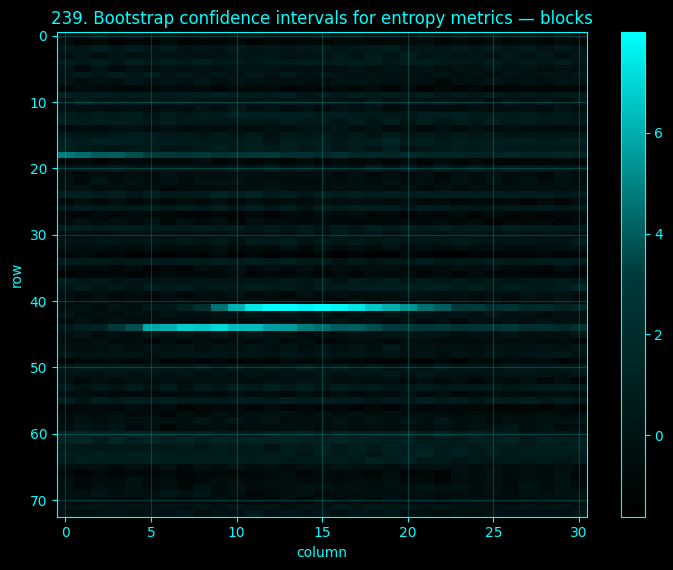

In [216]:
# =======================================================
# 239. Bootstrap confidence intervals for entropy metrics
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: A moving-block bootstrap resamples contiguous blocks so short-range temporal dependence
# is retained approximately. The 2.5% and 97.5% bootstrap quantiles form a nonparametric 95% interval
# for permutation entropy.
# =======================================================
def _entropy_method_239():
    y = _ent_y
    X = _ent_x
    rng = np.random.default_rng(1000 + 239)
    B = _ENT_SPEED['sur']
    n = len(y)
    L = max(8, int(0.25 * _ent_fs))
    vals = []
    for _ in range(_ENT_SPEED['boot']):
        blocks = []
        while sum(map(len, blocks)) < n:
            s = int(rng.integers(0, max(1, n - L + 1)))
            blocks.append(y[s:s + L])
        vals.append(_perm_entropy(np.concatenate(blocks)[:n]))
    lo, hi = np.quantile(vals, [0.025, 0.975])
    _ent_print_args = ['Permutation entropy bootstrap 95% CI=', (float(lo), float(hi)), 'estimate=', _perm_entropy(y)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_239()
_ent_auto_plot(239, 'Bootstrap confidence intervals for entropy metrics', _ent_method_ns, ['y', 'X', 'rng', 'B', 'n', 'L', 'vals', '_', '_ent_print_args', 'blocks', 'lo', 'hi', 's'])


### 240. Permutation significance for entropy metrics

Window-level channel entropy values are pooled and labels are randomly permuted under the null of exchangeability between the two channels. The p-value is the fraction of permuted mean differences at least as large in magnitude as the observed difference.

**Implementation.** The existing EEG segment and plotting conventions are reused. Expensive null ensembles and window counts obey `full / balanced / fast / ultra`; `full` retains the largest budgets.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


channel-window PE difference= 0.007692552186439605 permutation p= 0.2857142857142857


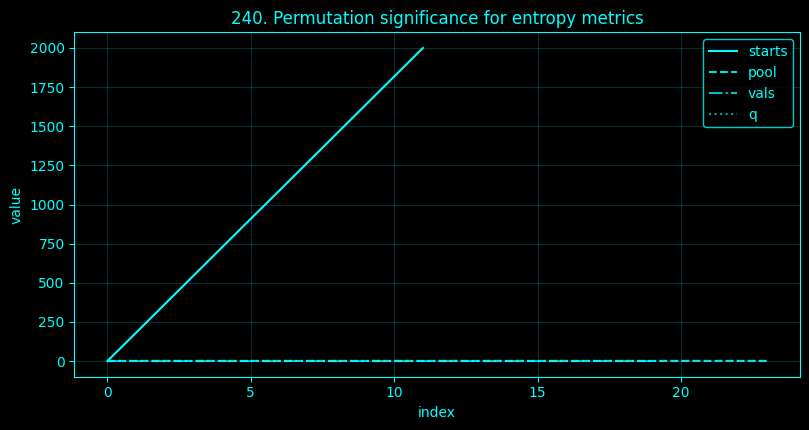

In [217]:
# =======================================================
# 240. Permutation significance for entropy metrics
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Window-level channel entropy values are pooled and labels are randomly permuted under
# the null of exchangeability between the two channels. The p-value is the fraction of permuted mean
# differences at least as large in magnitude as the observed difference.
# =======================================================
def _entropy_method_240():
    y = _ent_y
    X = _ent_x
    rng = np.random.default_rng(1000 + 240)
    B = _ENT_SPEED['sur']
    W = max(80, int(2 * _ent_fs))
    starts = np.linspace(0, max(0, len(X) - W), max(6, _ENT_SPEED['windows'])).astype(int)
    a = np.array([_perm_entropy(X[s:s + W, 0]) for s in starts])
    b = np.array([_perm_entropy(X[s:s + W, 1]) for s in starts])
    obs = float(np.mean(a) - np.mean(b))
    pool = np.r_[a, b]
    vals = []
    for _ in range(max(20, 4 * B)):
        q = rng.permutation(pool)
        vals.append(np.mean(q[:len(a)]) - np.mean(q[len(a):]))
    _ent_print_args = ['channel-window PE difference=', obs, 'permutation p=', _emp_p(abs(obs), np.abs(vals))]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_240()
_ent_auto_plot(240, 'Permutation significance for entropy metrics', _ent_method_ns, ['y', 'X', 'rng', 'B', 'W', 'starts', 'a', 'b', 'obs', 'pool', 'vals', '_', '_ent_print_args', 'q', 's'])


### 241. FDR-corrected entropy significance maps

Each channel obtains a surrogate-test p-value. Benjamini–Hochberg controls the expected false-discovery rate by sorting $p_{(k)}$ and comparing with $k\alpha/m$; adjusted q-values are reported.

**Implementation.** The existing EEG segment and plotting conventions are reused. Expensive null ensembles and window counts obey `full / balanced / fast / ultra`; `full` retains the largest budgets.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> When many hypotheses are tested, some small p-values occur by chance. Benjamini-Hochberg false-discovery-rate control ranks the p-values and chooses a threshold designed to limit the expected fraction of false discoveries among the results called significant. FDR control is less strict than controlling the probability of any false positive, which gives it more power in large exploratory analyses. The correction should be applied to a clearly defined family of related tests.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


,channel,PE,p,FDR_q,significant_q<0.05
0,Fp1,0.934594,0.166667,0.761905,False
1,Fpz,0.937975,0.500000,0.800000,False
2,Fp2,0.936229,0.166667,0.761905,False
3,F7,0.906518,0.166667,0.761905,False
4,F3,0.905574,0.333333,0.761905,False
5,Fz,0.902363,0.333333,0.761905,False
6,F4,0.895287,0.833333,0.919540,False
7,F8,0.908734,0.500000,0.800000,False
8,FC5,0.903325,0.666667,0.888889,False
9,FC1,0.891142,0.166667,0.761905,False


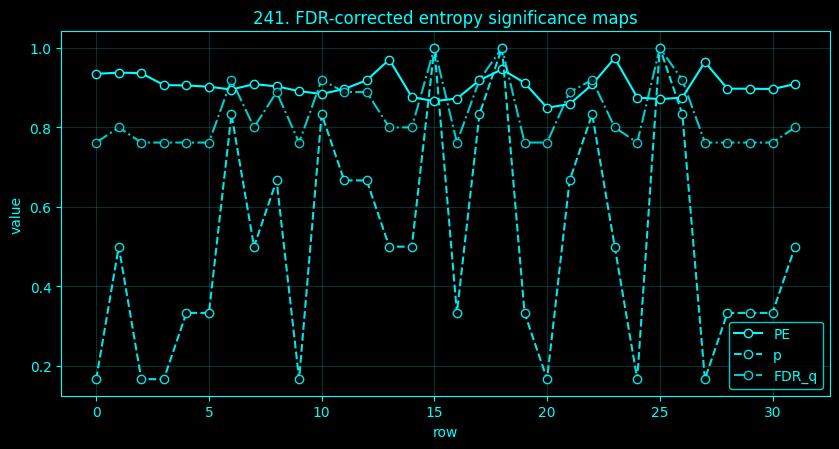

In [218]:
# =======================================================
# 241. FDR-corrected entropy significance maps
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Each channel obtains a surrogate-test p-value. Benjamini–Hochberg controls the expected
# false-discovery rate by sorting $p_{(k)}$ and comparing with $k\alpha/m$; adjusted q-values are
# reported.
# =======================================================
def _entropy_method_241():
    y = _ent_y
    X = _ent_x
    rng = np.random.default_rng(1000 + 241)
    B = _ENT_SPEED['sur']
    obs = []
    pv = []
    for j in range(X.shape[1]):
        o = _perm_entropy(X[:, j])
        null = [_perm_entropy(_phase_surrogate(X[:, j], rng)) for _ in range(B)]
        obs.append(o)
        pv.append(_emp_p(o, null, True))
    q = _bh(pv)
    _ent_display_result = pd.DataFrame({'channel': _ent_names, 'PE': obs, 'p': pv, 'FDR_q': q, 'significant_q<0.05': q < 0.05})
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_241()
_ent_auto_plot(241, 'FDR-corrected entropy significance maps', _ent_method_ns, ['y', 'X', 'rng', 'B', 'obs', 'pv', 'j', 'q', '_ent_display_result', 'o', 'null', '_'])


### 242. Entropy null-model atlas

The null-model atlas compares shuffle, phase-randomized, IAAFT and colored-noise ensembles using their null mean, standard deviation, z-score and empirical p-value for the same observed statistic.

**Implementation.** The existing EEG segment and plotting conventions are reused. Expensive null ensembles and window counts obey `full / balanced / fast / ultra`; `full` retains the largest budgets.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A p-value is the probability, under the specified null model, of obtaining a statistic at least as extreme as the observed one. It is not the probability that the null hypothesis is true and it does not measure effect size. A useful interpretation therefore combines the p-value with the observed magnitude, uncertainty, multiple-testing correction when relevant, and the assumptions of the null model.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


,null_model,mean_PE,sd_PE,z_observed,empirical_p
0,shuffle,0.999358,0.000345,-187.621764,0.166667
1,phase,0.953587,0.002121,-8.953889,0.166667
2,IAAFT,0.924899,0.003846,2.520742,0.166667
3,colored,0.930598,0.004512,0.885711,0.833333


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


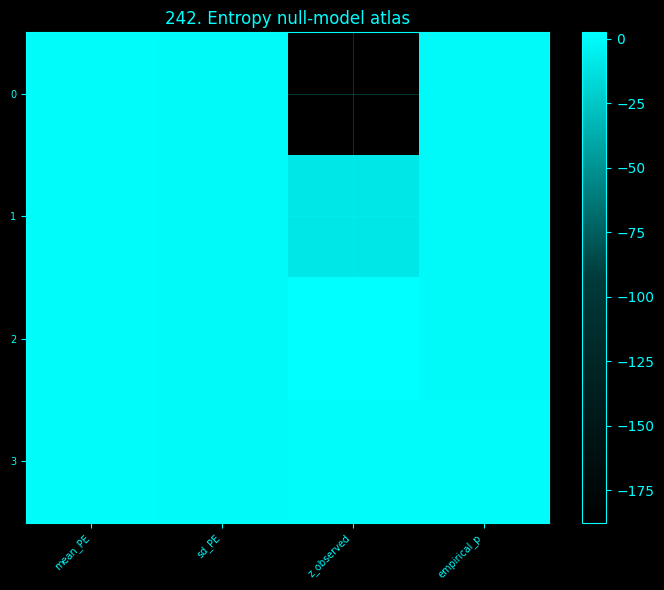

In [219]:
# =======================================================
# 242. Entropy null-model atlas
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: The null-model atlas compares shuffle, phase-randomized, IAAFT and colored-noise
# ensembles using their null mean, standard deviation, z-score and empirical p-value for the same
# observed statistic.
# =======================================================
def _entropy_method_242():
    y = _ent_y
    X = _ent_x
    rng = np.random.default_rng(1000 + 242)
    B = _ENT_SPEED['sur']
    obs = _perm_entropy(y)
    rows = []
    gens = {'shuffle': lambda: rng.permutation(y), 'phase': lambda: _phase_surrogate(y, rng), 'IAAFT': lambda: _iaaft(y, rng), 'colored': lambda: _colored_noise_like(y, rng)[0]}
    for name, gen in gens.items():
        v = np.array([_perm_entropy(gen()) for _ in range(B)])
        rows.append([name, np.mean(v), np.std(v), (obs - np.mean(v)) / (np.std(v) + ENT_EPS), _emp_p(obs, v, True)])
    _ent_display_result = pd.DataFrame(rows, columns=['null_model', 'mean_PE', 'sd_PE', 'z_observed', 'empirical_p'])
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_242()
_ent_auto_plot(242, 'Entropy null-model atlas', _ent_method_ns, ['y', 'X', 'rng', 'B', 'obs', 'rows', 'gens', '_ent_display_result', 'name', 'gen', 'v', '_'])


### 243. Entropy topography

Entropy topography maps one entropy statistic per channel. Here normalized permutation entropy is used as the displayed topographic value; the channel positions/data remain those of the existing EEG notebook.

**Implementation.** The existing EEG segment and plotting conventions are reused. Expensive null ensembles and window counts obey `full / balanced / fast / ultra`; `full` retains the largest budgets.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Permutation entropy replaces the exact amplitudes of short windows by their rank order. For example, a three-sample window is represented by which sample is smallest, middle, and largest. The probability distribution of these ordinal patterns is then summarized by Shannon entropy. This makes the measure relatively robust to monotonic amplitude transformations, while still being sensitive to temporal ordering. The embedding order and delay determine which time scales and pattern lengths are emphasized.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


,channel,entropy_topography
0,Fp1,0.934594
1,Fpz,0.937975
2,Fp2,0.936229
3,F7,0.906518
4,F3,0.905574
5,Fz,0.902363
6,F4,0.895287
7,F8,0.908734
8,FC5,0.903325
9,FC1,0.891142


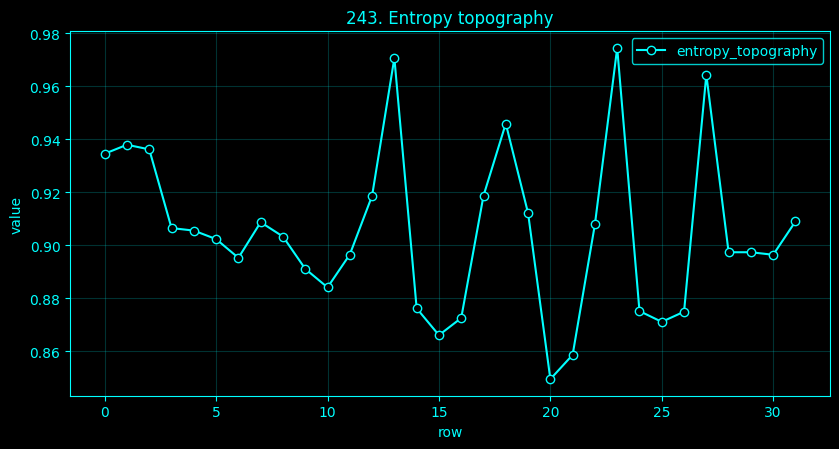

In [220]:
# =======================================================
# 243. Entropy topography
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Entropy topography maps one entropy statistic per channel. Here normalized permutation
# entropy is used as the displayed topographic value; the channel positions/data remain those of the
# existing EEG notebook.
# =======================================================
def _entropy_method_243():
    y = _ent_y
    X = _ent_x
    rng = np.random.default_rng(1000 + 243)
    B = _ENT_SPEED['sur']
    F = _channel_entropy_features()
    labels = ['amplitude_H', 'SampleEn', 'PermutationEn', 'DispersionEn', 'spectral_H', 'LZ']
    _ent_display_result = pd.DataFrame({'channel': _ent_names, 'entropy_topography': F[:, 2]})
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_243()
_ent_auto_plot(243, 'Entropy topography', _ent_method_ns, ['y', 'X', 'rng', 'B', 'F', 'labels', '_ent_display_result'])


### 244. Entropy regional summaries

Channel entropy fingerprints are averaged within broad frontal, central and posterior groups. The reported regional summaries keep each metric separate rather than averaging quantities with different scales.

**Implementation.** The existing EEG segment and plotting conventions are reused. Expensive null ensembles and window counts obey `full / balanced / fast / ultra`; `full` retains the largest budgets.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


,region,amplitude_H,SampleEn,PermutationEn,DispersionEn,spectral_H,LZ
0,frontal,0.772561,1.167869,0.908534,0.795252,0.581743,1.028816
1,central,0.887573,1.390153,0.909861,0.838349,0.580742,1.064079
2,posterior,0.908541,1.200533,0.899138,0.786296,0.540744,0.988889


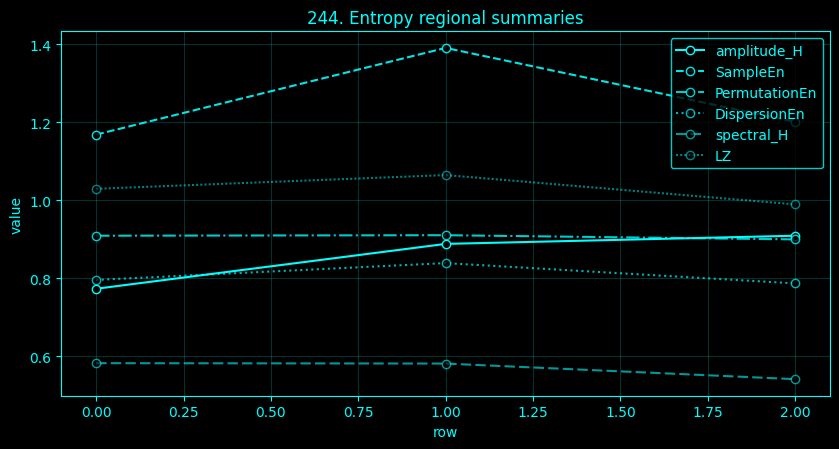

In [221]:
# =======================================================
# 244. Entropy regional summaries
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Channel entropy fingerprints are averaged within broad frontal, central and posterior
# groups. The reported regional summaries keep each metric separate rather than averaging quantities
# with different scales.
# =======================================================
def _entropy_method_244():
    y = _ent_y
    X = _ent_x
    rng = np.random.default_rng(1000 + 244)
    B = _ENT_SPEED['sur']
    F = _channel_entropy_features()
    labels = ['amplitude_H', 'SampleEn', 'PermutationEn', 'DispersionEn', 'spectral_H', 'LZ']
    rows = []
    for name, ids in _regions_indices().items():
        if ids:
            rows.append([name, *np.mean(F[ids], axis=0)])
    _ent_display_result = pd.DataFrame(rows, columns=['region'] + labels)
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_244()
_ent_auto_plot(244, 'Entropy regional summaries', _ent_method_ns, ['y', 'X', 'rng', 'B', 'F', 'labels', 'rows', '_ent_display_result', 'name', 'ids'])


### 245. Entropy left-right asymmetry

For homologous left/right electrodes, entropy asymmetry is $(H_L-H_R)/(|H_L|+|H_R|)$. Zero indicates equal entropy; the sign indicates lateralization under this normalization.

**Implementation.** The existing EEG segment and plotting conventions are reused. Expensive null ensembles and window counts obey `full / balanced / fast / ultra`; `full` retains the largest budgets.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


,left,right,PE_asymmetry
0,Fp1,Fp2,-0.000874
1,F7,F8,-0.001221
2,F3,F4,0.005712
3,FC5,FC6,0.003774
4,FC1,FC2,0.003949
5,T7,T8,0.027522
6,C3,C4,0.002086
7,CP5,CP6,0.002330
8,CP1,CP2,-0.005369
9,P7,P8,0.005206


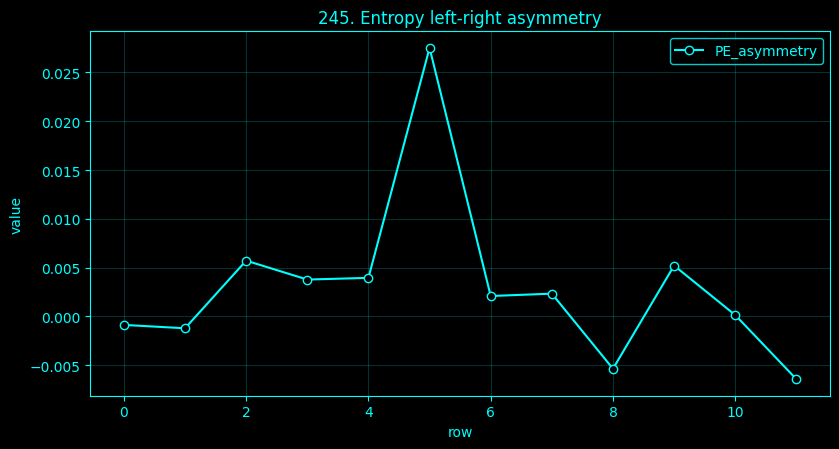

In [222]:
# =======================================================
# 245. Entropy left-right asymmetry
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: For homologous left/right electrodes, entropy asymmetry is $(H_L-H_R)/(|H_L|+|H_R|)$.
# Zero indicates equal entropy; the sign indicates lateralization under this normalization.
# =======================================================
def _entropy_method_245():
    y = _ent_y
    X = _ent_x
    rng = np.random.default_rng(1000 + 245)
    B = _ENT_SPEED['sur']
    F = _channel_entropy_features()
    labels = ['amplitude_H', 'SampleEn', 'PermutationEn', 'DispersionEn', 'spectral_H', 'LZ']
    idx = {n: k for k, n in enumerate(_ent_names)}
    pairs = [('Fp1', 'Fp2'), ('F7', 'F8'), ('F3', 'F4'), ('FC5', 'FC6'), ('FC1', 'FC2'), ('T7', 'T8'), ('C3', 'C4'), ('CP5', 'CP6'), ('CP1', 'CP2'), ('P7', 'P8'), ('P3', 'P4'), ('O1', 'O2')]
    rows = []
    for l, r in pairs:
        if l in idx and r in idx:
            a, b = (F[idx[l], 2], F[idx[r], 2])
            rows.append([l, r, (a - b) / (abs(a) + abs(b) + ENT_EPS)])
    _ent_display_result = pd.DataFrame(rows, columns=['left', 'right', 'PE_asymmetry'])
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_245()
_ent_auto_plot(245, 'Entropy left-right asymmetry', _ent_method_ns, ['y', 'X', 'rng', 'B', 'F', 'labels', 'idx', 'pairs', 'rows', '_ent_display_result', 'l', 'r', 'k', 'n', 'a', 'b'])


### 246. Entropy channel fingerprints

Each channel is represented by a multimetric entropy fingerprint: amplitude Shannon entropy, Sample Entropy, permutation entropy, dispersion entropy, spectral entropy and normalized Lempel–Ziv complexity.

**Implementation.** The existing EEG segment and plotting conventions are reused. Expensive null ensembles and window counts obey `full / balanced / fast / ultra`; `full` retains the largest budgets.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Permutation entropy replaces the exact amplitudes of short windows by their rank order. For example, a three-sample window is represented by which sample is smallest, middle, and largest. The probability distribution of these ordinal patterns is then summarized by Shannon entropy. This makes the measure relatively robust to monotonic amplitude transformations, while still being sensitive to temporal ordering. The embedding order and delay determine which time scales and pattern lengths are emphasized.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


,amplitude_H,SampleEn,PermutationEn,DispersionEn,spectral_H,LZ
Fp1,0.628117,0.743681,0.934594,0.677481,0.572924,0.895806
Fpz,0.572817,0.918675,0.937975,0.747429,0.588043,1.009638
Fp2,0.537751,0.803453,0.936229,0.685091,0.578813,1.044282
F7,0.903898,1.255840,0.906518,0.791493,0.648618,0.997265
F3,0.820030,1.380954,0.905574,0.851634,0.608454,1.073977
Fz,0.747467,1.111206,0.902363,0.786642,0.627191,1.002214
F4,0.806424,1.050801,0.895287,0.769448,0.602877,0.994790
F8,0.819509,1.444558,0.908734,0.857703,0.625924,1.064079
FC5,0.878387,1.532582,0.903325,0.868397,0.553337,1.106147
FC1,0.824561,1.186701,0.891142,0.825779,0.511733,1.024485


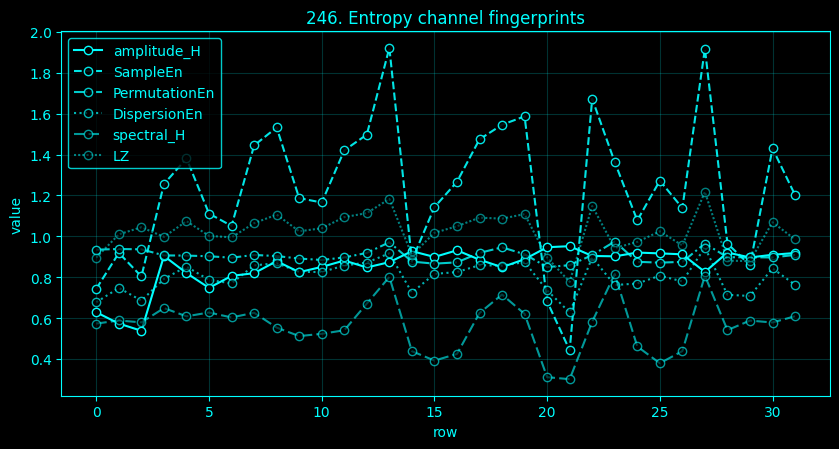

In [223]:
# =======================================================
# 246. Entropy channel fingerprints
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Each channel is represented by a multimetric entropy fingerprint: amplitude Shannon
# entropy, Sample Entropy, permutation entropy, dispersion entropy, spectral entropy and normalized
# Lempel–Ziv complexity.
# =======================================================
def _entropy_method_246():
    y = _ent_y
    X = _ent_x
    rng = np.random.default_rng(1000 + 246)
    B = _ENT_SPEED['sur']
    F = _channel_entropy_features()
    labels = ['amplitude_H', 'SampleEn', 'PermutationEn', 'DispersionEn', 'spectral_H', 'LZ']
    _ent_display_result = pd.DataFrame(F, columns=labels, index=_ent_names)
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_246()
_ent_auto_plot(246, 'Entropy channel fingerprints', _ent_method_ns, ['y', 'X', 'rng', 'B', 'F', 'labels', '_ent_display_result'])


### 247. Entropy clustering

Channel fingerprints are column-standardized and clustered by Euclidean k-means. Clustering is therefore performed in entropy-feature space, not on raw EEG waveforms.

**Implementation.** The existing EEG segment and plotting conventions are reused. Expensive null ensembles and window counts obey `full / balanced / fast / ultra`; `full` retains the largest budgets.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


,channel,entropy_cluster
0,Fp1,0
1,Fpz,0
2,Fp2,0
3,F7,1
4,F3,1
5,Fz,1
6,F4,1
7,F8,1
8,FC5,1
9,FC1,1


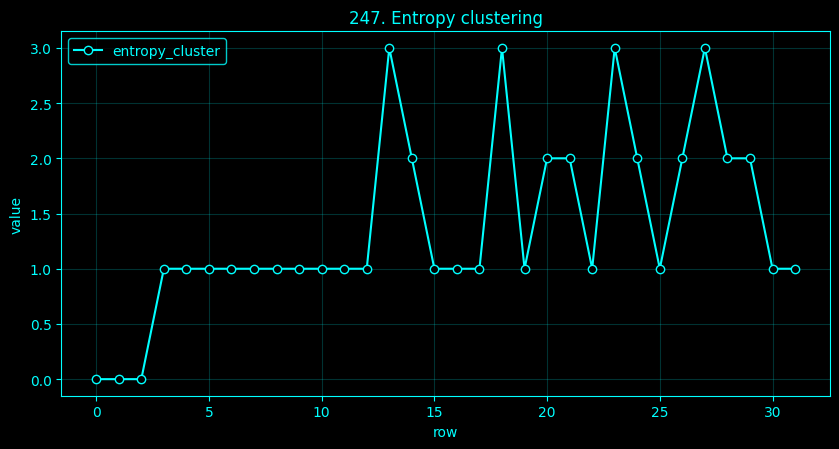

In [224]:
# =======================================================
# 247. Entropy clustering
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Channel fingerprints are column-standardized and clustered by Euclidean k-means.
# Clustering is therefore performed in entropy-feature space, not on raw EEG waveforms.
# =======================================================
def _entropy_method_247():
    y = _ent_y
    X = _ent_x
    rng = np.random.default_rng(1000 + 247)
    B = _ENT_SPEED['sur']
    F = _channel_entropy_features()
    labels = ['amplitude_H', 'SampleEn', 'PermutationEn', 'DispersionEn', 'spectral_H', 'LZ']
    Z = _zcols(F)
    K = min(4, len(Z))
    C = Z[np.linspace(0, len(Z) - 1, K).astype(int)]
    for _ in range(30):
        d = cdist(Z, C)
        lab = d.argmin(1)
        C = np.array([Z[lab == k].mean(0) if np.any(lab == k) else C[k] for k in range(K)])
    _ent_display_result = pd.DataFrame({'channel': _ent_names, 'entropy_cluster': lab})
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_247()
_ent_auto_plot(247, 'Entropy clustering', _ent_method_ns, ['y', 'X', 'rng', 'B', 'F', 'labels', 'Z', 'K', 'C', '_', '_ent_display_result', 'd', 'lab', 'k'])


### 248. Entropy PCA/UMAP embedding

PCA uses the singular-value decomposition of standardized entropy fingerprints. If the optional UMAP package is installed, UMAP is additionally computed; otherwise a spectral embedding is shown and explicitly labelled as a fallback rather than being called UMAP.

**Implementation.** The existing EEG segment and plotting conventions are reused. Expensive null ensembles and window counts obey `full / balanced / fast / ultra`; `full` retains the largest budgets.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


UMAP package unavailable: spectral embedding is shown as an explicitly labelled fallback; PCA is exact.


,channel,PC1,PC2,spectral_fallback1,spectral_fallback2
0,Fp1,1.555499,3.183599,0.034217,0.160899
1,Fpz,0.177552,2.993423,0.006962,0.157748
2,Fp2,0.587253,3.521999,0.016324,0.160763
3,F7,-0.139648,-0.049559,0.012278,0.073360
4,F3,-0.973309,-0.105270,-0.045269,0.026046
5,Fz,0.108507,1.027467,0.007797,0.118315
6,F4,0.544964,0.597483,0.030723,0.103245
7,F8,-1.152925,-0.071856,-0.063654,-0.002940
8,FC5,-1.205677,-0.926536,-0.076397,-0.029821
9,FC1,0.228107,-0.247575,0.024029,0.050986


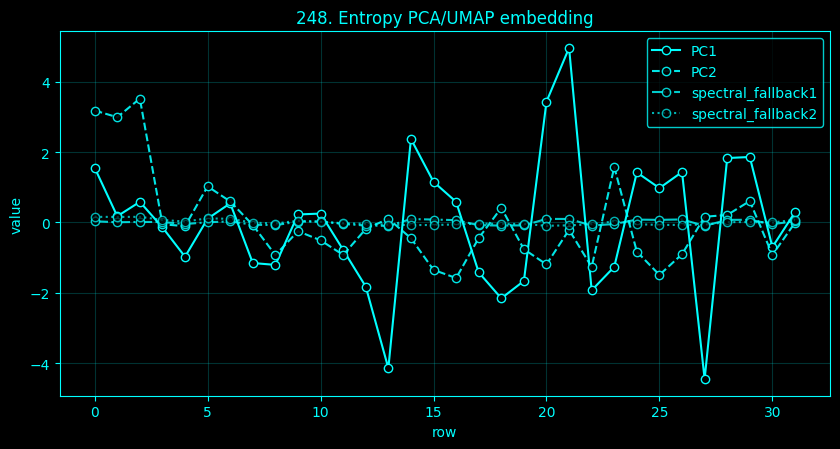

In [225]:
# =======================================================
# 248. Entropy PCA/UMAP embedding
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: PCA uses the singular-value decomposition of standardized entropy fingerprints. If the
# optional UMAP package is installed, UMAP is additionally computed; otherwise a spectral embedding is
# shown and explicitly labelled as a fallback rather than being called UMAP.
# =======================================================
def _entropy_method_248():
    y = _ent_y
    X = _ent_x
    rng = np.random.default_rng(1000 + 248)
    B = _ENT_SPEED['sur']
    F = _channel_entropy_features()
    labels = ['amplitude_H', 'SampleEn', 'PermutationEn', 'DispersionEn', 'spectral_H', 'LZ']
    Z = _zcols(F)
    U, S, Vt = np.linalg.svd(Z, full_matrices=False)
    P = U[:, :2] * S[:2]
    out = pd.DataFrame({'channel': _ent_names, 'PC1': P[:, 0], 'PC2': P[:, 1]})
    try:
        import umap
        E = umap.UMAP(n_components=2, random_state=248, n_neighbors=min(10, len(Z) - 1)).fit_transform(Z)
        out['UMAP1'] = E[:, 0]
        out['UMAP2'] = E[:, 1]
    except Exception:
        from sklearn.manifold import SpectralEmbedding
        E = SpectralEmbedding(n_components=2, n_neighbors=min(8, len(Z) - 1), random_state=248).fit_transform(Z)
        out['spectral_fallback1'] = E[:, 0]
        out['spectral_fallback2'] = E[:, 1]
        _ent_print_args = ['UMAP package unavailable: spectral embedding is shown as an explicitly labelled fallback; PCA is exact.']
        print(*_ent_print_args)
    _ent_display_result = out
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_248()
_ent_auto_plot(248, 'Entropy PCA/UMAP embedding', _ent_method_ns, ['y', 'X', 'rng', 'B', 'F', 'labels', 'Z', 'P', 'out', '_ent_display_result', 'U', 'S', 'Vt', 'E', '_ent_print_args'])


### 249. Entropy distance matrices

Entropy distance between channels is Euclidean distance between column-standardized multimetric entropy fingerprints. Standardization prevents a high-variance metric from dominating solely because of units.

**Implementation.** The existing EEG segment and plotting conventions are reused. Expensive null ensembles and window counts obey `full / balanced / fast / ultra`; `full` retains the largest budgets.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Standardization subtracts a reference mean and divides by a reference standard deviation. After this transformation, a value of zero corresponds to the reference mean and a value of +1 is one standard deviation above it. This is useful when channels or features have different numerical scales, but it also removes absolute amplitude information. The reference population used to compute the mean and standard deviation therefore matters for interpretation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


,Fp1,Fpz,Fp2,F7,F3,Fz,F4,F8,FC5,FC1,...,CP6,P7,P3,Pz,P4,P8,POz,O1,Oz,O2
Fp1,0.000000,1.722437,1.825768,3.847375,4.183475,2.722245,2.901498,4.262319,4.965240,3.719555,...,5.667109,4.237183,4.047834,4.745209,4.095145,6.742465,3.301599,3.016543,4.713490,3.660644
Fpz,1.722437,0.000000,1.054116,3.711782,3.422251,2.269300,2.782274,3.494544,4.232744,3.304071,...,4.832513,4.235189,4.230246,4.609483,4.267538,5.584648,4.027118,3.821561,4.212923,3.719680
Fp2,1.825768,1.054116,0.000000,4.359737,4.166445,2.963287,3.357205,4.270248,4.935285,3.976788,...,5.534324,4.851788,4.712845,5.129387,4.789358,6.283681,4.461114,4.223254,4.889431,4.294114
F7,3.847375,3.711782,4.359737,0.000000,1.512274,1.649525,1.300633,1.546625,1.937566,1.554275,...,2.529841,2.689363,1.931486,2.462658,2.049171,4.408944,2.057636,2.146196,1.329106,0.572496
F3,4.183475,3.422251,4.166445,1.512274,0.000000,1.604285,1.748507,0.288735,0.955771,1.242541,...,1.579739,3.440112,2.570483,2.504006,2.597216,3.553882,3.258856,3.351153,0.998384,1.910069
Fz,2.722245,2.269300,2.963287,1.649525,1.604285,0.000000,0.732368,1.709279,2.471022,1.403408,...,3.168097,3.349646,2.392411,2.860327,2.459829,4.726297,2.521001,2.410319,2.202088,1.800968
F4,2.901498,2.782274,3.357205,1.300633,1.748507,0.732368,0.000000,1.898090,2.451855,1.196226,...,3.192478,3.401857,1.754224,2.410262,1.880290,5.065171,1.912403,1.840329,2.005604,1.301056
F8,4.262319,3.494544,4.270248,1.546625,0.288735,1.709279,1.898090,0.000000,1.001139,1.450876,...,1.538225,3.308411,2.744751,2.685858,2.755517,3.374079,3.357406,3.450295,1.081772,1.981153
FC5,4.965240,4.232744,4.935285,1.937566,0.955771,2.471022,2.451855,1.001139,0.000000,1.642948,...,0.807720,3.885499,2.686956,2.281706,2.682770,3.476919,3.632967,3.841696,0.743326,2.257540
FC1,3.719555,3.304071,3.976788,1.554275,1.242541,1.403408,1.196226,1.450876,1.642948,0.000000,...,2.441130,3.943201,1.540293,1.588091,1.533179,4.766554,2.471145,2.618837,1.357633,1.659341


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


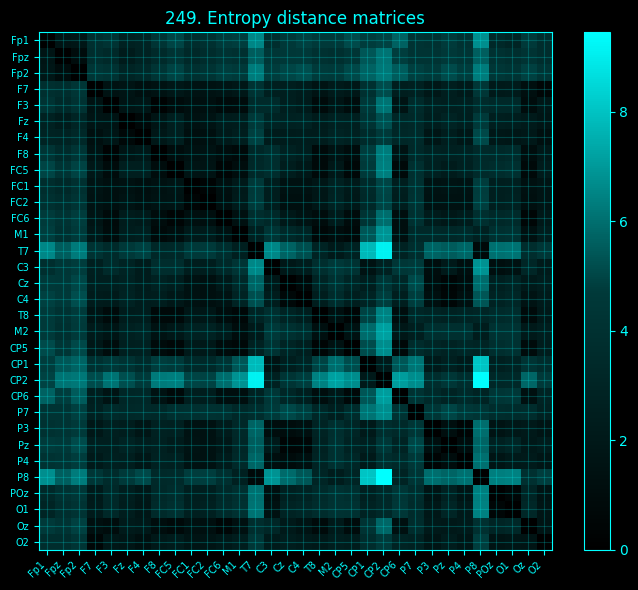

In [226]:
# =======================================================
# 249. Entropy distance matrices
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Entropy distance between channels is Euclidean distance between column-standardized
# multimetric entropy fingerprints. Standardization prevents a high-variance metric from dominating
# solely because of units.
# =======================================================
def _entropy_method_249():
    y = _ent_y
    X = _ent_x
    rng = np.random.default_rng(1000 + 249)
    B = _ENT_SPEED['sur']
    F = _channel_entropy_features()
    labels = ['amplitude_H', 'SampleEn', 'PermutationEn', 'DispersionEn', 'spectral_H', 'LZ']
    Z = _zcols(F)
    D = squareform(pdist(Z, 'euclidean'))
    _ent_display_result = pd.DataFrame(D, index=_ent_names, columns=_ent_names)
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_249()
_ent_auto_plot(249, 'Entropy distance matrices', _ent_method_ns, ['y', 'X', 'rng', 'B', 'F', 'labels', 'Z', 'D', '_ent_display_result'])


### 250. Entropy-based channel ranking

Channels are ranked across standardized entropy/complexity features and their mean feature rank is reported. This is a descriptive multimetric ranking, not a universal notion of “most entropic” channel.

**Implementation.** The existing EEG segment and plotting conventions are reused. Expensive null ensembles and window counts obey `full / balanced / fast / ultra`; `full` retains the largest budgets.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


,channel,mean_feature_rank
13,T7,28.000000
27,P8,27.500000
19,CP5,24.833333
22,CP6,24.666667
12,M1,24.166667
18,M2,24.000000
17,T8,23.500000
8,FC5,20.833333
7,F8,20.333333
23,P7,20.000000


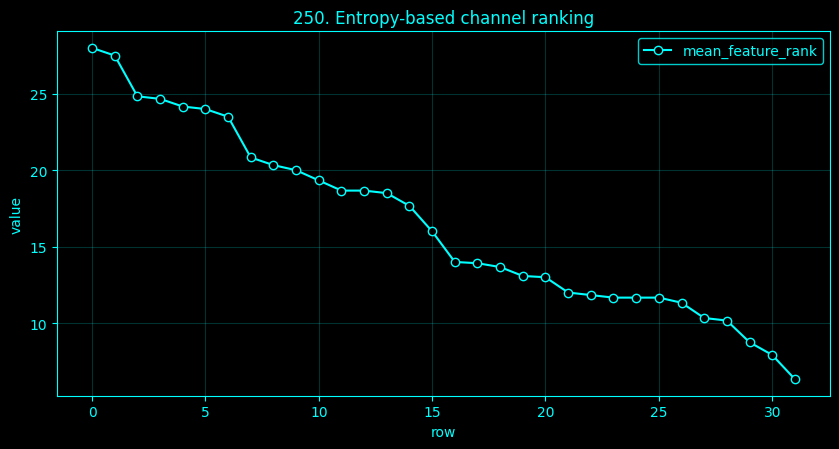

In [227]:
# =======================================================
# 250. Entropy-based channel ranking
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Channels are ranked across standardized entropy/complexity features and their mean
# feature rank is reported. This is a descriptive multimetric ranking, not a universal notion of “most
# entropic” channel.
# =======================================================
def _entropy_method_250():
    y = _ent_y
    X = _ent_x
    rng = np.random.default_rng(1000 + 250)
    B = _ENT_SPEED['sur']
    F = _channel_entropy_features()
    labels = ['amplitude_H', 'SampleEn', 'PermutationEn', 'DispersionEn', 'spectral_H', 'LZ']
    Z = _zcols(F)
    score = np.mean(stats.rankdata(Z, axis=0), axis=1)
    _ent_display_result = pd.DataFrame({'channel': _ent_names, 'mean_feature_rank': score}).sort_values('mean_feature_rank', ascending=False)
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_250()
_ent_auto_plot(250, 'Entropy-based channel ranking', _ent_method_ns, ['y', 'X', 'rng', 'B', 'F', 'labels', 'Z', 'score', '_ent_display_result'])


### 251. Entropy-based state segmentation

Sliding windows are represented by permutation entropy, dispersion entropy, spectral entropy and topographic entropy. Standardized feature vectors are clustered to produce discrete entropy-defined states.

**Implementation.** The existing EEG segment and plotting conventions are reused. Expensive null ensembles and window counts obey `full / balanced / fast / ultra`; `full` retains the largest budgets.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Permutation entropy replaces the exact amplitudes of short windows by their rank order. For example, a three-sample window is represented by which sample is smallest, middle, and largest. The probability distribution of these ordinal patterns is then summarized by Shannon entropy. This makes the measure relatively robust to monotonic amplitude transformations, while still being sensitive to temporal ordering. The embedding order and delay determine which time scales and pattern lengths are emphasized.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


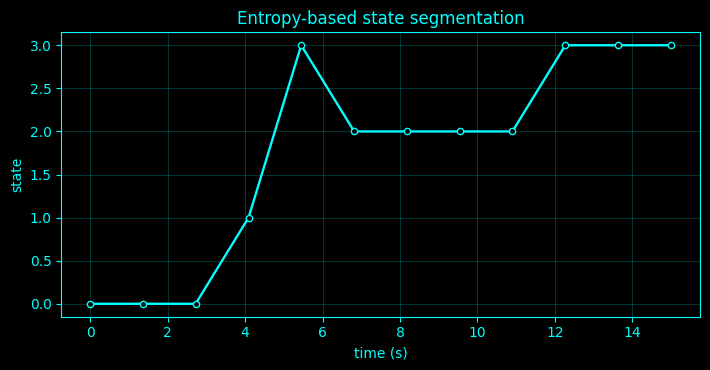

In [228]:
# =======================================================
# 251. Entropy-based state segmentation
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Sliding windows are represented by permutation entropy, dispersion entropy, spectral
# entropy and topographic entropy. Standardized feature vectors are clustered to produce discrete
# entropy-defined states.
# =======================================================
def _entropy_method_251():
    y = _ent_y
    X = _ent_x
    rng = np.random.default_rng(1000 + 251)
    B = _ENT_SPEED['sur']
    F = _channel_entropy_features()
    labels = ['amplitude_H', 'SampleEn', 'PermutationEn', 'DispersionEn', 'spectral_H', 'LZ']
    Z = _zcols(F)
    starts, WF = _window_entropy_features()
    WZ = _zcols(WF)
    K = min(4, len(WZ))
    C = WZ[np.linspace(0, len(WZ) - 1, K).astype(int)]
    for _ in range(30):
        d = cdist(WZ, C)
        lab = d.argmin(1)
        C = np.array([WZ[lab == k].mean(0) if np.any(lab == k) else C[k] for k in range(K)])
    _line(starts / _ent_fs, lab, 'Entropy-based state segmentation', 'time (s)', 'state')
    return locals()
_ent_method_ns = _entropy_method_251()


### 252. Entropy-based change-point detection

Change score is the Euclidean norm $\|z_t-z_{t-1}\|_2$ between consecutive standardized window entropy-feature vectors. Large values identify candidate entropy-regime changes; they are not automatically experimental events.

**Implementation.** The existing EEG segment and plotting conventions are reused. Expensive null ensembles and window counts obey `full / balanced / fast / ultra`; `full` retains the largest budgets.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


,time_s,change_score,candidate_change
0,0.000,0.000000,False
1,1.360,2.719589,True
2,2.720,0.844513,False
3,4.088,3.004446,True
4,5.448,2.857279,True
5,6.816,1.644108,False
6,8.176,0.828530,False
7,9.544,0.479097,False
8,10.904,0.920503,False
9,12.272,0.638199,False


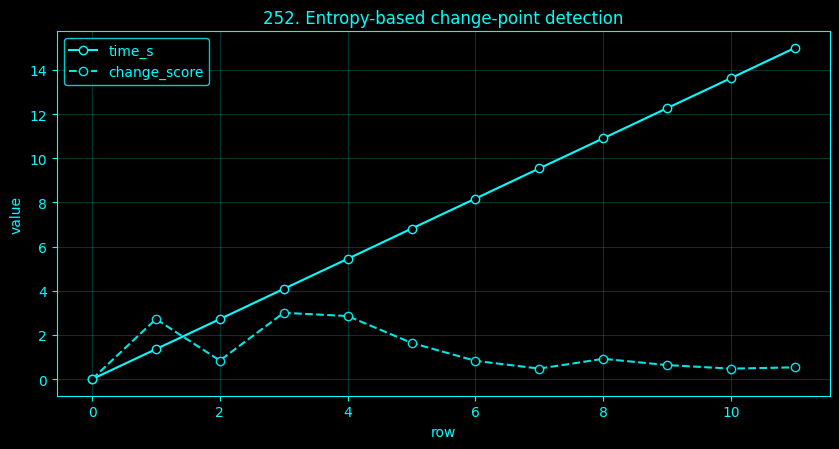

In [229]:
# =======================================================
# 252. Entropy-based change-point detection
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Change score is the Euclidean norm $\|z_t-z_{t-1}\|_2$ between consecutive standardized
# window entropy-feature vectors. Large values identify candidate entropy-regime changes; they are not
# automatically experimental events.
# =======================================================
def _entropy_method_252():
    y = _ent_y
    X = _ent_x
    rng = np.random.default_rng(1000 + 252)
    B = _ENT_SPEED['sur']
    F = _channel_entropy_features()
    labels = ['amplitude_H', 'SampleEn', 'PermutationEn', 'DispersionEn', 'spectral_H', 'LZ']
    Z = _zcols(F)
    starts, WF = _window_entropy_features()
    WZ = _zcols(WF)
    d = np.r_[0, np.linalg.norm(np.diff(WZ, axis=0), axis=1)]
    thr = np.quantile(d, 0.8) if len(d) > 2 else np.inf
    _ent_display_result = pd.DataFrame({'time_s': starts / _ent_fs, 'change_score': d, 'candidate_change': d >= thr})
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_252()
_ent_auto_plot(252, 'Entropy-based change-point detection', _ent_method_ns, ['y', 'X', 'rng', 'B', 'F', 'labels', 'Z', 'WZ', 'd', 'thr', '_ent_display_result', 'starts', 'WF'])


### 253. Entropy-event locking

For supplied event samples, entropy is measured in matched pre/post windows. If no event markers are provided, internally detected high-envelope peaks are used only as a clearly labelled demonstration and are not called stimuli.

**Implementation.** The existing EEG segment and plotting conventions are reused. Expensive null ensembles and window counts obey `full / balanced / fast / ultra`; `full` retains the largest budgets.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


internal high-envelope events (demonstration)


,event_sample,pre_PE,post_PE,post_minus_pre
0,1214,0.893400,0.853084,-0.040316
1,1333,0.839390,0.938054,0.098664
2,1627,0.926465,0.940862,0.014396
3,2106,0.884852,0.950764,0.065911
4,195,0.928709,0.896235,-0.032474
5,654,0.931784,0.937939,0.006154
6,299,0.932881,0.962206,0.029325
7,505,0.923112,0.948431,0.025319


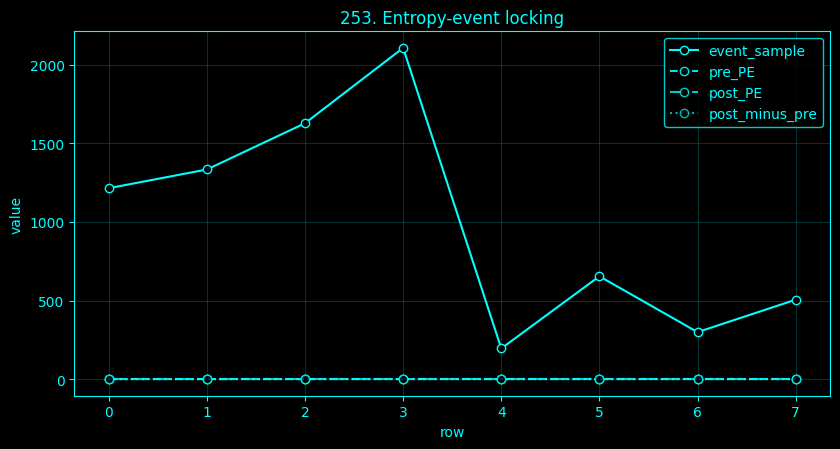

In [230]:
# =======================================================
# 253. Entropy-event locking
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: For supplied event samples, entropy is measured in matched pre/post windows. If no
# event markers are provided, internally detected high-envelope peaks are used only as a clearly
# labelled demonstration and are not called stimuli.
# =======================================================
def _entropy_method_253():
    y = _ent_y
    X = _ent_x
    rng = np.random.default_rng(1000 + 253)
    B = _ENT_SPEED['sur']
    F = _channel_entropy_features()
    labels = ['amplitude_H', 'SampleEn', 'PermutationEn', 'DispersionEn', 'spectral_H', 'LZ']
    Z = _zcols(F)
    starts, WF = _window_entropy_features()
    WZ = _zcols(WF)
    W = max(60, int(0.75 * _ent_fs))
    events = None
    label = ''
    events = globals().get('ENTROPY_EVENT_SAMPLES', None)
    label = 'supplied events'
    if events is None:
        env = np.abs(signal.hilbert(y))
        pk, _ = signal.find_peaks(env, distance=max(1, int(0.5 * _ent_fs)), prominence=np.std(env))
        events = pk[np.argsort(env[pk])[-min(8, len(pk)):]] if len(pk) else []
        label = 'internal high-envelope events (demonstration)'
    rows = []
    for e in events:
        e = int(e)
        if e - W >= 0 and e + W <= len(y):
            rows.append([e, _perm_entropy(y[e - W:e]), _perm_entropy(y[e:e + W])])
    df = pd.DataFrame(rows, columns=['event_sample', 'pre_PE', 'post_PE'])
    if len(df):
        df['post_minus_pre'] = df.post_PE - df.pre_PE
    _ent_print_args = [label]
    print(*_ent_print_args)
    _ent_display_result = df
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_253()
_ent_auto_plot(253, 'Entropy-event locking', _ent_method_ns, ['y', 'X', 'rng', 'B', 'F', 'labels', 'Z', 'WZ', 'W', 'events', 'label', 'rows', 'e', 'df', '_ent_print_args', '_ent_display_result', 'starts', 'WF', 'env', 'pk', '_'])


### 254. Entropy burst locking

Alpha-envelope peaks define oscillatory burst centers. Pre/post permutation entropy around each burst quantifies whether local ordinal-pattern diversity changes around internally detected bursts.

**Implementation.** The existing EEG segment and plotting conventions are reused. Expensive null ensembles and window counts obey `full / balanced / fast / ultra`; `full` retains the largest budgets.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Permutation entropy replaces the exact amplitudes of short windows by their rank order. For example, a three-sample window is represented by which sample is smallest, middle, and largest. The probability distribution of these ordinal patterns is then summarized by Shannon entropy. This makes the measure relatively robust to monotonic amplitude transformations, while still being sensitive to temporal ordering. The embedding order and delay determine which time scales and pattern lengths are emphasized.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


internally detected alpha-envelope bursts


,event_sample,pre_PE,post_PE,post_minus_pre
0,1040,0.936046,0.910451,-0.025595
1,699,0.936794,0.949885,0.013090
2,201,0.927167,0.892226,-0.034941
3,1413,0.938054,0.891054,-0.047000
4,580,0.973107,0.956058,-0.017050
5,1353,0.905124,0.936046,0.030922
6,405,0.941237,0.889030,-0.052206
7,1560,0.915035,0.927797,0.012761
8,298,0.921449,0.969549,0.048100
9,500,0.889908,0.968562,0.078654


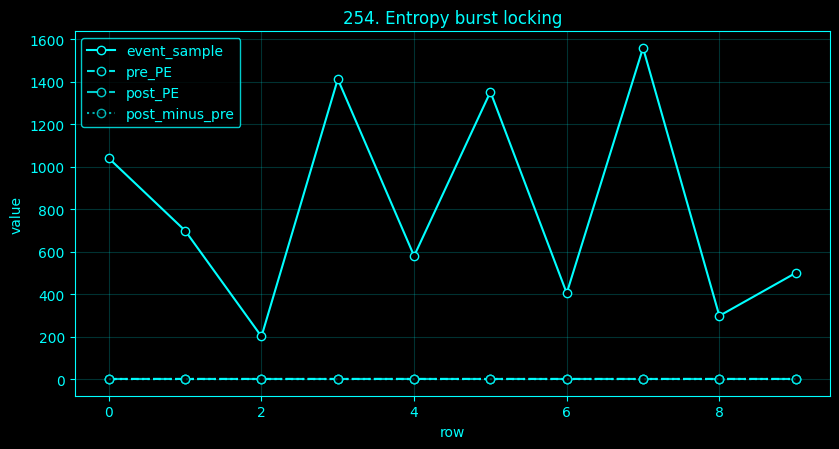

In [231]:
# =======================================================
# 254. Entropy burst locking
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Alpha-envelope peaks define oscillatory burst centers. Pre/post permutation entropy
# around each burst quantifies whether local ordinal-pattern diversity changes around internally
# detected bursts.
# =======================================================
def _entropy_method_254():
    y = _ent_y
    X = _ent_x
    rng = np.random.default_rng(1000 + 254)
    B = _ENT_SPEED['sur']
    F = _channel_entropy_features()
    labels = ['amplitude_H', 'SampleEn', 'PermutationEn', 'DispersionEn', 'spectral_H', 'LZ']
    Z = _zcols(F)
    starts, WF = _window_entropy_features()
    WZ = _zcols(WF)
    W = max(60, int(0.75 * _ent_fs))
    events = None
    label = ''
    env = np.abs(signal.hilbert(_band(y, 8, min(13, 0.45 * _ent_fs))))
    pk, _ = signal.find_peaks(env, distance=max(1, int(0.4 * _ent_fs)), prominence=np.std(env))
    events = pk[np.argsort(env[pk])[-min(10, len(pk)):]] if len(pk) else []
    label = 'internally detected alpha-envelope bursts'
    rows = []
    for e in events:
        e = int(e)
        if e - W >= 0 and e + W <= len(y):
            rows.append([e, _perm_entropy(y[e - W:e]), _perm_entropy(y[e:e + W])])
    df = pd.DataFrame(rows, columns=['event_sample', 'pre_PE', 'post_PE'])
    if len(df):
        df['post_minus_pre'] = df.post_PE - df.pre_PE
    _ent_print_args = [label]
    print(*_ent_print_args)
    _ent_display_result = df
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_254()
_ent_auto_plot(254, 'Entropy burst locking', _ent_method_ns, ['y', 'X', 'rng', 'B', 'F', 'labels', 'Z', 'WZ', 'W', 'events', 'label', 'env', 'rows', 'e', 'df', '_ent_print_args', '_ent_display_result', 'starts', 'WF', 'pk', '_'])


### 255. Entropy stimulation-response analysis

True stimulation-response analysis requires stimulation timestamps. When `ENTROPY_STIM_SAMPLES` is supplied, pre/post entropy is computed around those samples. Without markers, the notebook prints an explicit warning and shows only a demonstration using internal peaks.

**Implementation.** The existing EEG segment and plotting conventions are reused. Expensive null ensembles and window counts obey `full / balanced / fast / ultra`; `full` retains the largest budgets.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


NO stimulation markers supplied — internal high-envelope events shown only as a demonstration


,event_sample,pre_PE,post_PE,post_minus_pre
0,299,0.932881,0.962206,0.029325
1,505,0.923112,0.948431,0.025319


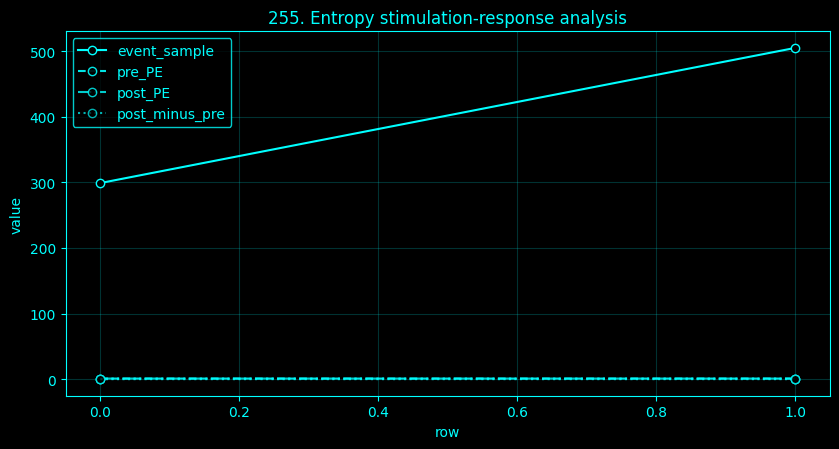

In [232]:
# =======================================================
# 255. Entropy stimulation-response analysis
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: True stimulation-response analysis requires stimulation timestamps. When
# `ENTROPY_STIM_SAMPLES` is supplied, pre/post entropy is computed around those samples. Without
# markers, the notebook prints an explicit warning and shows only a demonstration using internal
# peaks.
# =======================================================
def _entropy_method_255():
    y = _ent_y
    X = _ent_x
    rng = np.random.default_rng(1000 + 255)
    B = _ENT_SPEED['sur']
    F = _channel_entropy_features()
    labels = ['amplitude_H', 'SampleEn', 'PermutationEn', 'DispersionEn', 'spectral_H', 'LZ']
    Z = _zcols(F)
    starts, WF = _window_entropy_features()
    WZ = _zcols(WF)
    W = max(60, int(0.75 * _ent_fs))
    events = None
    label = ''
    events = globals().get('ENTROPY_STIM_SAMPLES', None)
    label = 'supplied stimulation events'
    if events is None:
        env = np.abs(signal.hilbert(y))
        pk, _ = signal.find_peaks(env, distance=max(1, int(0.8 * _ent_fs)), prominence=1.5 * np.std(env))
        events = pk[np.argsort(env[pk])[-min(6, len(pk)):]] if len(pk) else []
        label = 'NO stimulation markers supplied — internal high-envelope events shown only as a demonstration'
    rows = []
    for e in events:
        e = int(e)
        if e - W >= 0 and e + W <= len(y):
            rows.append([e, _perm_entropy(y[e - W:e]), _perm_entropy(y[e:e + W])])
    df = pd.DataFrame(rows, columns=['event_sample', 'pre_PE', 'post_PE'])
    if len(df):
        df['post_minus_pre'] = df.post_PE - df.pre_PE
    _ent_print_args = [label]
    print(*_ent_print_args)
    _ent_display_result = df
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_255()
_ent_auto_plot(255, 'Entropy stimulation-response analysis', _ent_method_ns, ['y', 'X', 'rng', 'B', 'F', 'labels', 'Z', 'WZ', 'W', 'events', 'label', 'rows', 'e', 'df', '_ent_print_args', '_ent_display_result', 'starts', 'WF', 'env', 'pk', '_'])


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and role — dynamical and maximum-entropy helpers for methods 256–275</h3>
<p>This block supports finite partition entropy rates, topological/metric-entropy estimates, correlation entropy \(K_2\), irreversibility and entropy production, and maximum-entropy models. For a stationary Markov chain, the implemented entropy-production rate uses \(\tfrac12\sum_{ij}(\pi_iP_{ij}-\pi_jP_{ji})\log[(\pi_iP_{ij})/(\pi_jP_{ji})]\). Finite-data KS/Pesin-related cells are explicitly diagnostics or bounds, not theorem-level identification.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [233]:
# =======================================================
# Shared primitives only; numbered cells below contain the method-specific mathematics.
# SHARED NUMERICAL PRIMITIVES — methods 256–275
# Dynamical entropy, irreversibility and maximum-entropy models.
# =======================================================
from scipy.optimize import minimize, brentq

def _entropy_rate_blocks(sym,maxL=6):
    H=np.array([_block_entropy(sym,L) for L in range(1,maxL+1)],float);d=np.diff(np.r_[0,H]);return H,d

def _corrsum(y,m,r):
    X=_embed(_cap(y, {'full':4500,'balanced':3000,'fast':1800,'ultra':900}[FAST_OPTION]),m,1,cap=False)
    if len(X)<3:return np.nan
    pairs=len(cKDTree(X).query_pairs(float(r),p=np.inf));return pairs/max(1,len(X)*(len(X)-1)/2)

def _k2_curve(y,m=3):
    yy=_cap(y, {'full':4500,'balanced':3000,'fast':1800,'ultra':900}[FAST_OPTION]);sd=np.std(yy);rs=np.geomspace(.08*sd,.5*sd,8);vals=[]
    for r in rs:
        c1=_corrsum(yy,m,r);c2=_corrsum(yy,m+1,r);vals.append(np.log((c1+ENT_EPS)/(c2+ENT_EPS))*_ent_fs)
    return rs,np.asarray(vals)

def _symbol_transition_matrix(sym,K=None):
    s=np.asarray(sym,int);K=int(K or (s.max()+1 if len(s) else 1));C=np.zeros((K,K),float)
    for a,b in zip(s[:-1],s[1:]):C[a,b]+=1
    P=C/(C.sum(1,keepdims=True)+ENT_EPS);return C,P

def _markov_epr(sym):
    C,P=_symbol_transition_matrix(sym);pi=C.sum(1);pi=_safe_prob(pi);e=0.
    for a in range(len(pi)):
        for b in range(len(pi)):
            f=pi[a]*P[a,b];r=pi[b]*P[b,a]
            if f>0 and r>0:e+=f*np.log(f/r)
    return float(e)

def _path_reverse_div(sym,L=3,js=False):
    s=np.asarray(sym,int);X=sliding_window_view(s,L);f=Counter(map(tuple,X));r=Counter(tuple(x[::-1]) for x in X);keys=sorted(set(f)|set(r));p=np.array([f[k]+.5 for k in keys],float);q=np.array([r[k]+.5 for k in keys],float);p=_safe_prob(p);q=_safe_prob(q);return _jsd(p,q) if js else _kl(p,q)

def _local_expansion_proxy(y,horizon=1):
    yy=_cap(y, {'full':7000,'balanced':4500,'fast':2500,'ultra':1200}[FAST_OPTION]);m=3;E=_embed(yy,m,1,cap=False);h=int(horizon);n=len(E)-h
    if n<20:return np.nan
    E0=E[:n];E1=E[h:h+n];k=min(20,max(6,int(np.sqrt(n))));tree=cKDTree(E0);ids=np.linspace(0,n-1,min(n,120 if FAST_OPTION=='full' else 80 if FAST_OPTION=='balanced' else 50 if FAST_OPTION=='fast' else 30)).astype(int);G=[]
    for ix in ids:
        nn=tree.query(E0[ix],k=k)[1];A=E0[nn]-E0[ix];B=E1[nn]-E1[ix];J=np.linalg.lstsq(A,B,rcond=1e-6)[0].T;s=np.linalg.svd(J,compute_uv=False);G.append(np.prod(s[s>1]) if np.any(s>1) else 1.)
    return float(np.log(np.mean(G)+ENT_EPS)/(h/_ent_fs))

def _linear_lyap_sum(X=None):
    X=np.asarray(_ent_x[:,:min(8,_ent_x.shape[1])] if X is None else X,float);A=X[:-1];B=X[1:];ridge=1e-3;M=np.linalg.solve(A.T@A+ridge*np.eye(A.shape[1]),A.T@B).T;e=np.linalg.eigvals(M);le=np.log(np.maximum(np.abs(e),ENT_EPS))*_ent_fs;return float(np.sum(le[le>0])),le

def _binary_states(X=None,nch=6):
    X=np.asarray(_ent_x if X is None else X,float)[:,:min(nch,_ent_x.shape[1])];return (X>np.median(X,axis=0,keepdims=True)).astype(int)

def _independent_maxent(B):
    p=np.clip(np.mean(B,axis=0),1e-6,1-1e-6);h=np.log(p/(1-p));return p,h

def _ising_fit(B):
    B=np.asarray(B,int);S=2*B-1;n=S.shape[1];states=np.array(list(__import__('itertools').product([-1.,1.],repeat=n)));pairs=list(__import__('itertools').combinations(range(n),2));emp1=S.mean(0);emp2=np.array([np.mean(S[:,a]*S[:,b]) for a,b in pairs])
    def feats(st):return np.c_[st,np.column_stack([st[:,a]*st[:,b] for a,b in pairs])]
    F=feats(states);target=np.r_[emp1,emp2]
    def obj(th):
        z=F@th;logZ=special.logsumexp(z);p=np.exp(z-logZ);return float(logZ-th@target), F.T@p-target
    res=minimize(lambda th:obj(th)[0],np.zeros(F.shape[1]),jac=lambda th:obj(th)[1],method='L-BFGS-B',options={'maxiter':{'full':300,'balanced':200,'fast':120,'ultra':70}[FAST_OPTION]});z=F@res.x;p=np.exp(z-special.logsumexp(z));return states,p,res.x,float(res.fun),bool(res.success)

def _soft_state_model(F,K=4,tau=1.0):
    Z=_zcols(F);K=min(K,len(Z));C=Z[np.linspace(0,len(Z)-1,K).astype(int)]
    for _ in range(25):
        D=cdist(Z,C,'sqeuclidean');lab=D.argmin(1);C=np.array([Z[lab==k].mean(0) if np.any(lab==k) else C[k] for k in range(K)])
    E=cdist(Z,C,'sqeuclidean');logp=-E/max(tau,ENT_EPS);logp-=special.logsumexp(logp,axis=1,keepdims=True);P=np.exp(logp);return Z,C,E,P


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Execution router — entropy methods 256–275</h3>
<p>This cell routes the selected dynamical, irreversibility, entropy-production, or maximum-entropy calculation to the helpers above. It contains branching/output logic only; the estimator definitions remain those documented for each method.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


**Explicit implementation note — methods 256–275.**  
The catalogue dispatcher has been removed. Each numbered method below now contains its own executable mathematics in that method's code cell. Only reusable numerical primitives and the shared black/cyan plotting utilities remain centralized.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


### 256. Direct symbolic Kolmogorov-Sinai entropy

Kolmogorov–Sinai entropy is $h_{KS}=\sup_{\mathcal P}h_\mu(T,\mathcal P)$ over finite measurable partitions. A single symbolic partition can only provide $h_\mu(T,\mathcal P)$; this cell estimates it from the asymptotic block-entropy increment $H_{L+1}-H_L$ and explicitly does not claim the supremum is known.

**Implementation.** The formulas are evaluated on the same EEG segment. Finite-data proxies are labelled as such, and computational budgets follow `full / balanced / fast / ultra`.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


finite symbolic partition entropy-rate estimate= 66.61491352784068 nats/s; block entropies= [1.38629397 2.34497948 2.97903533 3.59809095 4.1479691  4.66392957] This is partition-specific, not the exact KS supremum.


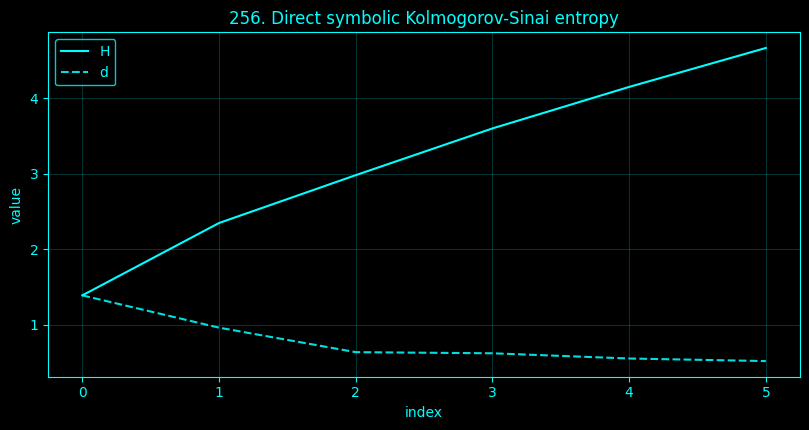

In [234]:
# =======================================================
# 256. Direct symbolic Kolmogorov-Sinai entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Kolmogorov–Sinai entropy is $h_{KS}=\sup_{\mathcal P}h_\mu(T,\mathcal P)$ over finite
# measurable partitions. A single symbolic partition can only provide $h_\mu(T,\mathcal P)$; this cell
# estimates it from the asymptotic block-entropy increment $H_{L+1}-H_L$ and explicitly does not claim
# the supremum is known.
# =======================================================
def _entropy_method_256():
    y = _ent_y
    sym = _symbolize(y, 4)
    H, d = _entropy_rate_blocks(sym, 6)
    _ent_print_args = ['finite symbolic partition entropy-rate estimate=', float(np.mean(d[-2:])) * _ent_fs, 'nats/s; block entropies=', H, 'This is partition-specific, not the exact KS supremum.']
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_256()
_ent_auto_plot(256, 'Direct symbolic Kolmogorov-Sinai entropy', _ent_method_ns, ['y', 'sym', '_ent_print_args', 'H', 'd'])


### 257. Partition-based KS entropy

For each tested quantile partition $\mathcal P_K$, the finite-order entropy rate is estimated from block-entropy increments. The maximum across the tested partitions is a finite-search lower-bound style diagnostic, not an exact KS entropy unless a generating partition is established.

**Implementation.** The formulas are evaluated on the same EEG segment. Finite-data proxies are labelled as such, and computational budgets follow `full / balanced / fast / ultra`.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


,quantile_partition_K,rate_nats_per_sample,rate_nats_per_s
0,2,0.243347,30.418340
1,3,0.428339,53.542381
2,4,0.584467,73.058360
3,6,0.752930,94.116267
4,8,0.844096,105.512050


maximum over tested finite partitions= 105.51204983007656 nats/s (lower-bound style finite search, not a proof of h_KS)


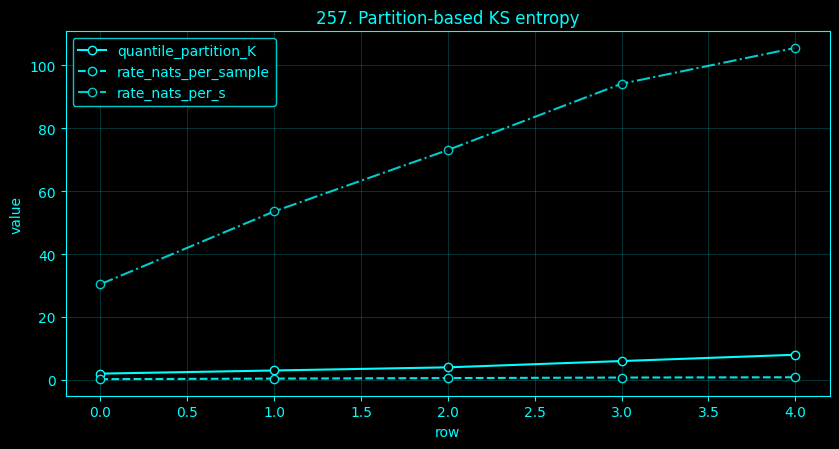

In [235]:
# =======================================================
# 257. Partition-based KS entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: For each tested quantile partition $\mathcal P_K$, the finite-order entropy rate is
# estimated from block-entropy increments. The maximum across the tested partitions is a finite-search
# lower-bound style diagnostic, not an exact KS entropy unless a generating partition is established.
# =======================================================
def _entropy_method_257():
    y = _ent_y
    sym = _symbolize(y, 4)
    rows = []
    for K in [2, 3, 4, 6, 8]:
        s = _symbolize(y, K)
        H, d = _entropy_rate_blocks(s, 5)
        rows.append([K, float(np.mean(d[-2:])), float(np.mean(d[-2:])) * _ent_fs])
    df = pd.DataFrame(rows, columns=['quantile_partition_K', 'rate_nats_per_sample', 'rate_nats_per_s'])
    _ent_display_result = df
    display(_ent_display_result)
    _ent_print_args = ['maximum over tested finite partitions=', df.rate_nats_per_s.max(), 'nats/s (lower-bound style finite search, not a proof of h_KS)']
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_257()
_ent_auto_plot(257, 'Partition-based KS entropy', _ent_method_ns, ['y', 'sym', 'rows', 'K', 'df', '_ent_display_result', '_ent_print_args', 's', 'H', 'd'])


### 258. Generating-partition entropy estimate

Ordinal patterns can act as generating partitions for important classes of one-dimensional dynamics under additional assumptions. The cell computes the ordinal-pattern entropy rate but labels it a candidate generating-partition estimate because those assumptions are not established for EEG.

**Implementation.** The formulas are evaluated on the same EEG segment. Finite-data proxies are labelled as such, and computational budgets follow `full / balanced / fast / ultra`.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


ordinal candidate-generating partition entropy rate= 112.5771482931257 nats/s; generating property is not assumed without dynamical-system conditions


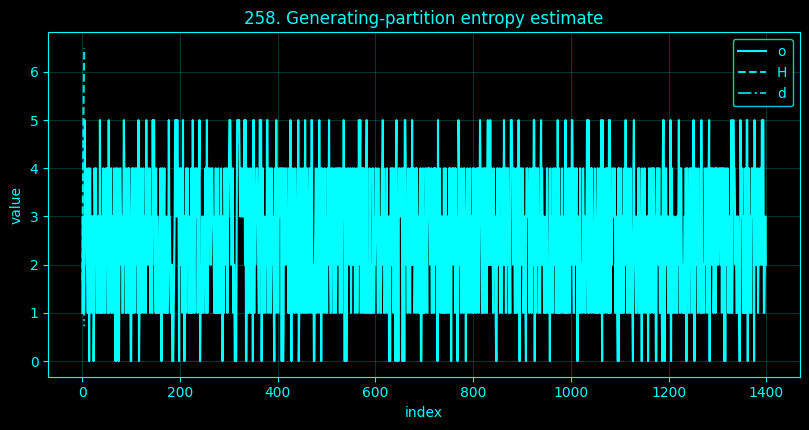

In [236]:
# =======================================================
# 258. Generating-partition entropy estimate
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Ordinal patterns can act as generating partitions for important classes of one-
# dimensional dynamics under additional assumptions. The cell computes the ordinal-pattern entropy
# rate but labels it a candidate generating-partition estimate because those assumptions are not
# established for EEG.
# =======================================================
def _entropy_method_258():
    y = _ent_y
    sym = _symbolize(y, 4)
    o = _ordinal_seq(y, 3)
    H, d = _entropy_rate_blocks(o, 5)
    _ent_print_args = ['ordinal candidate-generating partition entropy rate=', float(np.mean(d[-2:])) * _ent_fs, 'nats/s; generating property is not assumed without dynamical-system conditions']
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_258()
_ent_auto_plot(258, 'Generating-partition entropy estimate', _ent_method_ns, ['y', 'sym', 'o', '_ent_print_args', 'H', 'd'])


### 259. Correlation entropy K2

Correlation entropy $K_2$ is estimated from correlation sums by $K_2(r,m)\approx \tau^{-1}\ln[C_m(r)/C_{m+1}(r)]$. A radius sweep is shown so a finite plateau can be inspected instead of reporting one arbitrary tolerance as the asymptotic invariant.

**Implementation.** The formulas are evaluated on the same EEG segment. Finite-data proxies are labelled as such, and computational budgets follow `full / balanced / fast / ultra`.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol τ (tau) commonly denotes a time delay, scale, or characteristic time. Here it should be read according to the definition immediately preceding the formula.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


,radius,K2_nats_per_s
0,0.079763,228.988629
1,0.103634,192.739342
2,0.134647,165.012965
3,0.174942,134.806318
4,0.227296,103.050677
5,0.295317,77.778909
6,0.383695,55.521387
7,0.498521,37.905517


finite K2 plateau estimate= 118.92849727346218


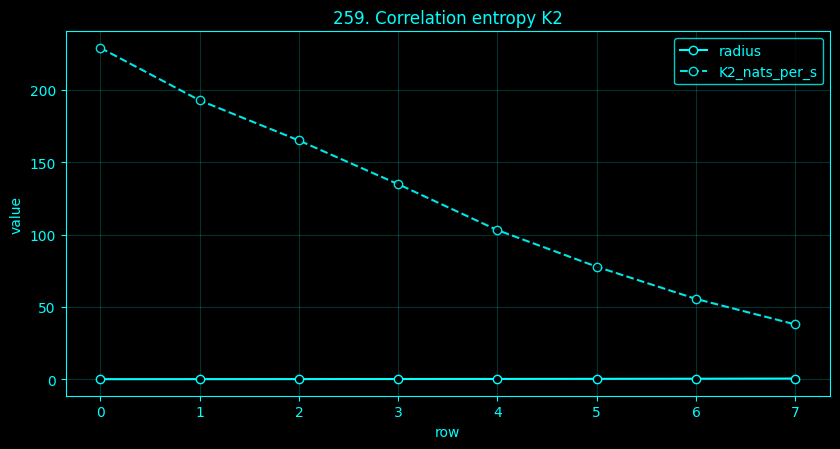

In [237]:
# =======================================================
# 259. Correlation entropy K2
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Correlation entropy $K_2$ is estimated from correlation sums by $K_2(r,m)\approx
# \tau^{-1}\ln[C_m(r)/C_{m+1}(r)]$. A radius sweep is shown so a finite plateau can be inspected
# instead of reporting one arbitrary tolerance as the asymptotic invariant.
# =======================================================
def _entropy_method_259():
    y = _ent_y
    sym = _symbolize(y, 4)
    r, k = _k2_curve(y, 3)
    _ent_display_result = pd.DataFrame({'radius': r, 'K2_nats_per_s': k})
    display(_ent_display_result)
    _ent_print_args = ['finite K2 plateau estimate=', float(np.nanmedian(k[2:-2])) if len(k) > 4 else float(np.nanmedian(k))]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_259()
_ent_auto_plot(259, 'Correlation entropy K2', _ent_method_ns, ['y', 'sym', '_ent_display_result', '_ent_print_args', 'r', 'k'])


### 260. Approximate entropy-rate via correlation sums

This cell reports the finite correlation-sum rate $\tau^{-1}\ln[C_m(r)/C_{m+1}(r)]$ at fixed $m$ and $r$. It is an approximation to a correlation-entropy rate, not an $m\to\infty,r\to0$ limit.

**Implementation.** The formulas are evaluated on the same EEG segment. Finite-data proxies are labelled as such, and computational budgets follow `full / balanced / fast / ultra`.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Approximate entropy is also based on repeated short patterns, but unlike Sample Entropy it includes self-matches in its probability estimates. Larger values usually indicate that patterns are less predictable from one step to the next. Because self-matches introduce finite-sample bias, Approximate Entropy and Sample Entropy should not be treated as numerically interchangeable even when they are computed with the same embedding length and tolerance.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


In [238]:
# =======================================================
# 260. Approximate entropy-rate via correlation sums
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: This cell reports the finite correlation-sum rate $\tau^{-1}\ln[C_m(r)/C_{m+1}(r)]$ at
# fixed $m$ and $r$. It is an approximation to a correlation-entropy rate, not an $m\to\infty,r\to0$
# limit.
# =======================================================
def _entropy_method_260():
    y = _ent_y
    sym = _symbolize(y, 4)
    sd = np.std(y)
    c3 = _corrsum(y, 3, 0.2 * sd)
    c4 = _corrsum(y, 4, 0.2 * sd)
    _ent_print_args = ['finite correlation-sum entropy-rate approximation=', np.log((c3 + ENT_EPS) / (c4 + ENT_EPS)) * _ent_fs, 'nats/s']
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_260()
_ent_auto_plot(260, 'Approximate entropy-rate via correlation sums', _ent_method_ns, ['y', 'sym', 'sd', 'c3', 'c4', '_ent_print_args'])


finite correlation-sum entropy-rate approximation= 119.09907877910565 nats/s


### 261. Topological entropy

For the observed symbolic transition graph with adjacency matrix $A_{ij}=1$ when transition $i\to j$ occurs, the subshift-of-finite-type topological entropy is $h_{top}=\ln\rho(A)$ per symbol. Multiplying by sample rate expresses the constructed symbolic-model rate per second.

**Implementation.** The formulas are evaluated on the same EEG segment. Finite-data proxies are labelled as such, and computational budgets follow `full / balanced / fast / ultra`.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ρ (rho) is often used for a correlation, density, or similarity measure; its role is determined by the equation's definition.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


topological entropy of observed transition subshift ln rho(A)= 158.7745791421115 nats/s


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


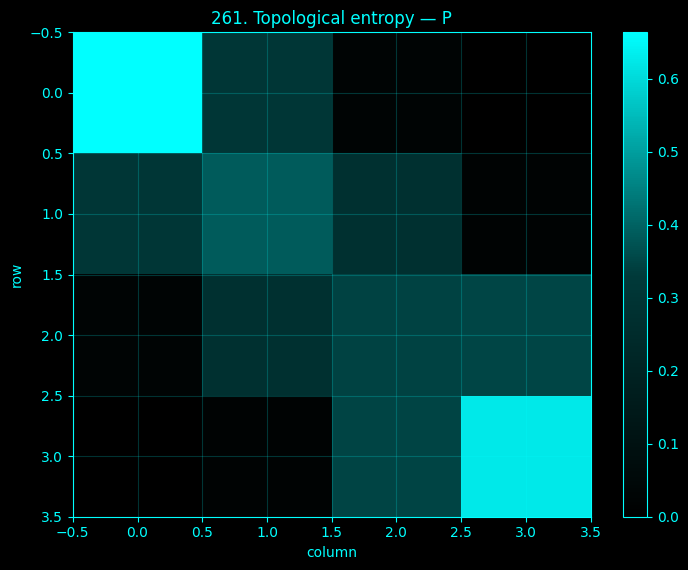

In [239]:
# =======================================================
# 261. Topological entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: For the observed symbolic transition graph with adjacency matrix $A_{ij}=1$ when
# transition $i\to j$ occurs, the subshift-of-finite-type topological entropy is $h_{top}=\ln\rho(A)$
# per symbol. Multiplying by sample rate expresses the constructed symbolic-model rate per second.
# =======================================================
def _entropy_method_261():
    y = _ent_y
    sym = _symbolize(y, 4)
    C, P = _symbol_transition_matrix(sym)
    A = (C > 0).astype(float)
    rho = max(abs(np.linalg.eigvals(A))) if len(A) else 1.0
    _ent_print_args = ['topological entropy of observed transition subshift ln rho(A)=', float(np.log(max(rho, ENT_EPS))) * _ent_fs, 'nats/s']
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_261()
_ent_auto_plot(261, 'Topological entropy', _ent_method_ns, ['y', 'sym', 'A', 'rho', '_ent_print_args', 'C', 'P'])


### 262. Metric entropy

Given stationary transition probabilities $P_{ij}$ and state probabilities $\pi_i$, first-order metric/Shannon entropy rate is $h=-\sum_i\pi_i\sum_jP_{ij}\ln P_{ij}$. This is measure-dependent and differs from topological entropy.

**Implementation.** The formulas are evaluated on the same EEG segment. Finite-data proxies are labelled as such, and computational budgets follow `full / balanced / fast / ultra`.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


first-order metric/Shannon entropy rate= 119.83567670084675 nats/s


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


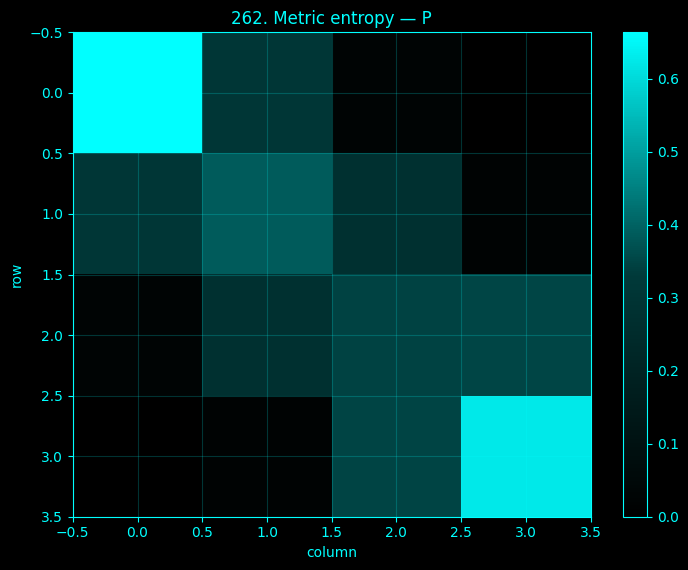

In [240]:
# =======================================================
# 262. Metric entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Given stationary transition probabilities $P_{ij}$ and state probabilities $\pi_i$,
# first-order metric/Shannon entropy rate is $h=-\sum_i\pi_i\sum_jP_{ij}\ln P_{ij}$. This is measure-
# dependent and differs from topological entropy.
# =======================================================
def _entropy_method_262():
    y = _ent_y
    sym = _symbolize(y, 4)
    C, P = _symbol_transition_matrix(sym)
    pi = _safe_prob(C.sum(1))
    h = -sum((pi[a] * P[a, b] * np.log(P[a, b] + ENT_EPS) for a in range(len(pi)) for b in range(len(pi)) if P[a, b] > 0))
    _ent_print_args = ['first-order metric/Shannon entropy rate=', float(h) * _ent_fs, 'nats/s']
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_262()
_ent_auto_plot(262, 'Metric entropy', _ent_method_ns, ['y', 'sym', 'pi', 'h', '_ent_print_args', 'C', 'P', 'a', 'b'])


### 263. Expansion entropy independent of Lyapunov spectra

Expansion entropy can be defined without explicitly extracting Lyapunov exponents through $H_0\approx t^{-1}\ln\langle G(D\Phi^t)\rangle$, where $G(A)$ is the product of singular values of $A$ that exceed one. The cell estimates local finite-horizon Jacobians from delay-space neighborhoods and reports this finite-data proxy.

**Implementation.** The formulas are evaluated on the same EEG segment. Finite-data proxies are labelled as such, and computational budgets follow `full / balanced / fast / ultra`.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


,horizon_samples,finite_expansion_entropy_proxy_nats_per_s
0,1,73.816385
1,2,71.498095
2,4,64.018590


Uses log(mean product of singular values >1) / horizon; finite-data local-map estimate.


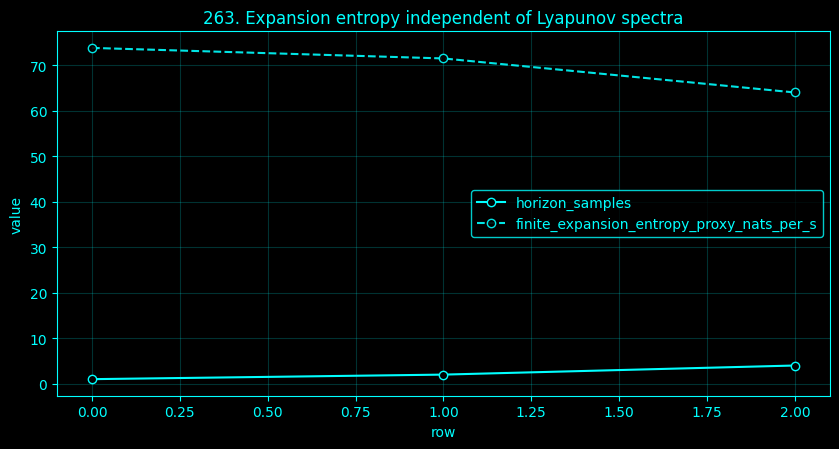

In [241]:
# =======================================================
# 263. Expansion entropy independent of Lyapunov spectra
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Expansion entropy can be defined without explicitly extracting Lyapunov exponents
# through $H_0\approx t^{-1}\ln\langle G(D\Phi^t)\rangle$, where $G(A)$ is the product of singular
# values of $A$ that exceed one. The cell estimates local finite-horizon Jacobians from delay-space
# neighborhoods and reports this finite-data proxy.
# =======================================================
def _entropy_method_263():
    y = _ent_y
    sym = _symbolize(y, 4)
    vals = []
    for h in [1, 2, 4]:
        vals.append([h, _local_expansion_proxy(y, h)])
    _ent_display_result = pd.DataFrame(vals, columns=['horizon_samples', 'finite_expansion_entropy_proxy_nats_per_s'])
    display(_ent_display_result)
    _ent_print_args = ['Uses log(mean product of singular values >1) / horizon; finite-data local-map estimate.']
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_263()
_ent_auto_plot(263, 'Expansion entropy independent of Lyapunov spectra', _ent_method_ns, ['y', 'sym', 'vals', 'h', '_ent_display_result', '_ent_print_args'])


### 264. Pesin-identity validation

Pesin’s identity $h_\mu=\sum_{\lambda_i>0}\lambda_i$ requires strong smooth-dynamical and invariant-measure hypotheses. The cell only compares a symbolic metric-entropy estimate with positive exponents of a fitted linear one-step model; agreement/disagreement is a diagnostic, not validation of the theorem’s hypotheses.

**Implementation.** The formulas are evaluated on the same EEG segment. Finite-data proxies are labelled as such, and computational budgets follow `full / balanced / fast / ultra`.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


{'symbolic_metric_entropy_nats_per_s': 119.83567670084675, 'sum_positive_linear_model_Lyapunov_per_s': 0.0, 'difference': 119.83567670084675, 'note': 'diagnostic only; Pesin identity requires hypotheses not established by EEG data'}


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


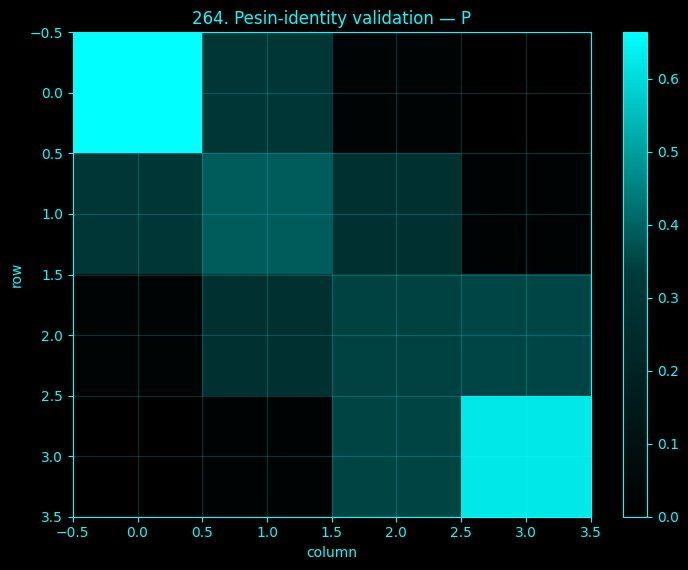

In [242]:
# =======================================================
# 264. Pesin-identity validation
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Pesin’s identity $h_\mu=\sum_{\lambda_i>0}\lambda_i$ requires strong smooth-dynamical
# and invariant-measure hypotheses. The cell only compares a symbolic metric-entropy estimate with
# positive exponents of a fitted linear one-step model; agreement/disagreement is a diagnostic, not
# validation of the theorem’s hypotheses.
# =======================================================
def _entropy_method_264():
    y = _ent_y
    sym = _symbolize(y, 4)
    C, P = _symbol_transition_matrix(sym)
    pi = _safe_prob(C.sum(1))
    h = -sum((pi[a] * P[a, b] * np.log(P[a, b] + ENT_EPS) for a in range(len(pi)) for b in range(len(pi)) if P[a, b] > 0)) * _ent_fs
    ls, le = _linear_lyap_sum()
    _ent_print_args = [{'symbolic_metric_entropy_nats_per_s': float(h), 'sum_positive_linear_model_Lyapunov_per_s': ls, 'difference': float(h - ls), 'note': 'diagnostic only; Pesin identity requires hypotheses not established by EEG data'}]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_264()
_ent_auto_plot(264, 'Pesin-identity validation', _ent_method_ns, ['y', 'sym', 'pi', 'h', '_ent_print_args', 'C', 'P', 'ls', 'le', 'a', 'b'])


### 265. Entropy production rate

For a stationary Markov chain, entropy production per step is $\sigma=\sum_{ij}\pi_iP_{ij}\ln[(\pi_iP_{ij})/(\pi_jP_{ji})]\ge0$ when all reverse fluxes are represented. It vanishes under detailed balance.

**Implementation.** The formulas are evaluated on the same EEG segment. Finite-data proxies are labelled as such, and computational budgets follow `full / balanced / fast / ultra`.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


In [243]:
# =======================================================
# 265. Entropy production rate
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: For a stationary Markov chain, entropy production per step is
# $\sigma=\sum_{ij}\pi_iP_{ij}\ln[(\pi_iP_{ij})/(\pi_jP_{ji})]\ge0$ when all reverse fluxes are
# represented. It vanishes under detailed balance.
# =======================================================
def _entropy_method_265():
    y = _ent_y
    sym = _symbolize(y, 4)
    _ent_print_args = ['first-order Markov entropy-production rate=', _markov_epr(sym) * _ent_fs, 'nats/s']
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_265()
_ent_auto_plot(265, 'Entropy production rate', _ent_method_ns, ['y', 'sym', '_ent_print_args'])


first-order Markov entropy-production rate= 0.003834641589981722 nats/s


### 266. Irreversibility entropy

Irreversibility is measured as KL divergence between empirical forward transition-path probabilities and their time-reversed probabilities. At first-order stationarity this is closely related to Markov entropy production.

**Implementation.** The formulas are evaluated on the same EEG segment. Finite-data proxies are labelled as such, and computational budgets follow `full / balanced / fast / ultra`.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


In [244]:
# =======================================================
# 266. Irreversibility entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Irreversibility is measured as KL divergence between empirical forward transition-path
# probabilities and their time-reversed probabilities. At first-order stationarity this is closely
# related to Markov entropy production.
# =======================================================
def _entropy_method_266():
    y = _ent_y
    sym = _symbolize(y, 4)
    _ent_print_args = ['irreversibility KL of forward vs reversed transition paths=', _path_reverse_div(sym, 2, False) * _ent_fs, 'nats/s-equivalent at one-step path length']
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_266()
_ent_auto_plot(266, 'Irreversibility entropy', _ent_method_ns, ['y', 'sym', '_ent_print_args'])


irreversibility KL of forward vs reversed transition paths= 0.003695222433989072 nats/s-equivalent at one-step path length


### 267. Time-reversal entropy asymmetry

Scalar Shannon entropy is invariant to simply reversing a sequence. Therefore time-reversal asymmetry is measured from the Jensen–Shannon divergence between forward and reversed length-3 path distributions, not from a false difference $H(x)-H(x^{rev})$.

**Implementation.** The formulas are evaluated on the same EEG segment. Finite-data proxies are labelled as such, and computational budgets follow `full / balanced / fast / ultra`.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


In [245]:
# =======================================================
# 267. Time-reversal entropy asymmetry
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Scalar Shannon entropy is invariant to simply reversing a sequence. Therefore time-
# reversal asymmetry is measured from the Jensen–Shannon divergence between forward and reversed
# length-3 path distributions, not from a false difference $H(x)-H(x^{rev})$.
# =======================================================
def _entropy_method_267():
    y = _ent_y
    sym = _symbolize(y, 4)
    _ent_print_args = ['time-reversal entropy asymmetry JSD of length-3 paths=', _path_reverse_div(sym, 3, True)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_267()
_ent_auto_plot(267, 'Time-reversal entropy asymmetry', _ent_method_ns, ['y', 'sym', '_ent_print_args'])


time-reversal entropy asymmetry JSD of length-3 paths= 0.0003049406835857828


### 268. Arrow-of-time entropy

An arrow-of-time score is formed from the bounded Jensen–Shannon divergence between length-4 path distributions and their reversed counterparts. Zero means the selected path statistics are time-reversal symmetric.

**Implementation.** The formulas are evaluated on the same EEG segment. Finite-data proxies are labelled as such, and computational budgets follow `full / balanced / fast / ultra`.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


In [246]:
# =======================================================
# 268. Arrow-of-time entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: An arrow-of-time score is formed from the bounded Jensen–Shannon divergence between
# length-4 path distributions and their reversed counterparts. Zero means the selected path statistics
# are time-reversal symmetric.
# =======================================================
def _entropy_method_268():
    y = _ent_y
    sym = _symbolize(y, 4)
    _ent_print_args = ['arrow-of-time bounded JSD of length-4 forward/reverse paths=', _path_reverse_div(sym, 4, True)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_268()
_ent_auto_plot(268, 'Arrow-of-time entropy', _ent_method_ns, ['y', 'sym', '_ent_print_args'])


arrow-of-time bounded JSD of length-4 forward/reverse paths= 0.0021019511794532772


### 269. Thermodynamic entropy analogs

A mathematical thermodynamic analogue assigns channel cost $E_i=\tfrac12\mathrm{Var}(x_i)$ and Gibbs weights $p_i(\beta)=e^{-\beta E_i}/Z$. The entropy $S=-\sum_ip_i\ln p_i$ and mean cost $U=\sum_ip_iE_i$ are thermodynamic-form quantities, not physical EEG thermodynamic entropy.

**Implementation.** The formulas are evaluated on the same EEG segment. Finite-data proxies are labelled as such, and computational budgets follow `full / balanced / fast / ultra`.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


,beta,mean_energy_analogue,Gibbs_entropy
0,0.25,0.5,3.465736
1,0.50,0.5,3.465736
2,1.00,0.5,3.465736
3,2.00,0.5,3.465736
4,4.00,0.5,3.465736


Mathematical thermodynamic analogue only; channel variance is used as an energy-like cost.


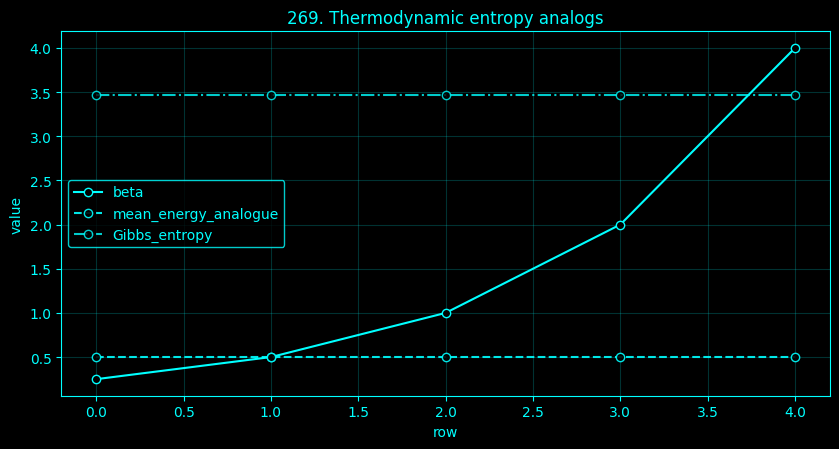

In [247]:
# =======================================================
# 269. Thermodynamic entropy analogs
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: A mathematical thermodynamic analogue assigns channel cost
# $E_i=\tfrac12\mathrm{Var}(x_i)$ and Gibbs weights $p_i(\beta)=e^{-\beta E_i}/Z$. The entropy
# $S=-\sum_ip_i\ln p_i$ and mean cost $U=\sum_ip_iE_i$ are thermodynamic-form quantities, not physical
# EEG thermodynamic entropy.
# =======================================================
def _entropy_method_269():
    y = _ent_y
    sym = _symbolize(y, 4)
    E = 0.5 * np.var(_ent_x, axis=0)
    betas = np.array([0.25, 0.5, 1, 2, 4])
    rows = []
    for b in betas:
        p = _safe_prob(np.exp(-b * (E - E.min())))
        rows.append([b, float(np.sum(p * E)), _H(p)])
    _ent_display_result = pd.DataFrame(rows, columns=['beta', 'mean_energy_analogue', 'Gibbs_entropy'])
    display(_ent_display_result)
    _ent_print_args = ['Mathematical thermodynamic analogue only; channel variance is used as an energy-like cost.']
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_269()
_ent_auto_plot(269, 'Thermodynamic entropy analogs', _ent_method_ns, ['y', 'sym', 'E', 'betas', 'rows', 'b', '_ent_display_result', '_ent_print_args', 'p'])


### 270. Maximum entropy model fitting

Maximum entropy subject only to binary first moments $\langle s_i\rangle$ factorizes: $P(s)\propto\exp(\sum_i h_is_i)$, with Bernoulli logit field $h_i=\ln[p_i/(1-p_i)]$. This cell fits that exact first-moment MaxEnt model.

**Implementation.** The formulas are evaluated on the same EEG segment. Finite-data proxies are labelled as such, and computational budgets follow `full / balanced / fast / ultra`.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


,channel,observed_activation_mean,maxent_field_logit
0,Fp1,0.5,0.0
1,Fpz,0.5,0.0
2,Fp2,0.5,0.0
3,F7,0.5,0.0
4,F3,0.5,0.0
5,Fz,0.5,0.0


With only first-moment constraints, the maximum-entropy model factorizes into Bernoulli variables.


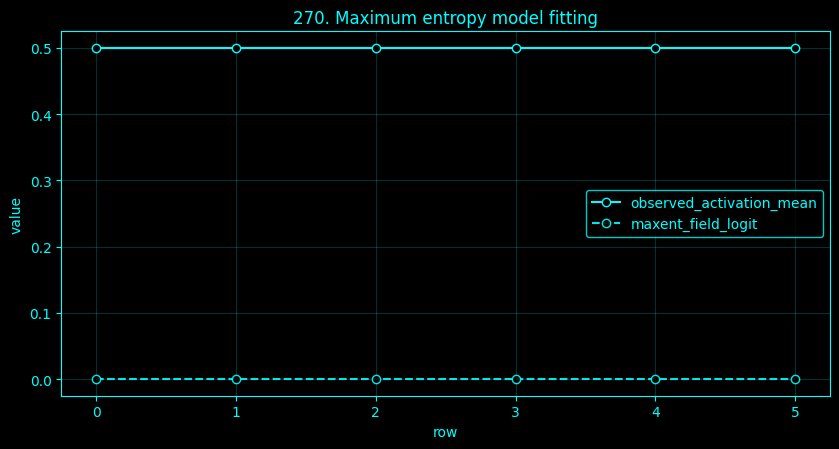

In [248]:
# =======================================================
# 270. Maximum entropy model fitting
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Maximum entropy subject only to binary first moments $\langle s_i\rangle$ factorizes:
# $P(s)\propto\exp(\sum_i h_is_i)$, with Bernoulli logit field $h_i=\ln[p_i/(1-p_i)]$. This cell fits
# that exact first-moment MaxEnt model.
# =======================================================
def _entropy_method_270():
    y = _ent_y
    sym = _symbolize(y, 4)
    B = _binary_states(nch=6)
    p, h = _independent_maxent(B)
    _ent_display_result = pd.DataFrame({'channel': _ent_names[:len(p)], 'observed_activation_mean': p, 'maxent_field_logit': h})
    display(_ent_display_result)
    _ent_print_args = ['With only first-moment constraints, the maximum-entropy model factorizes into Bernoulli variables.']
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_270()
_ent_auto_plot(270, 'Maximum entropy model fitting', _ent_method_ns, ['y', 'sym', 'B', '_ent_display_result', '_ent_print_args', 'p', 'h'])


### 271. Maximum entropy pairwise Ising model

The pairwise maximum-entropy Ising model is $P(s)=Z^{-1}\exp(\sum_ih_is_i+\sum_{i<j}J_{ij}s_is_j)$. For six binarized channels all $2^6$ states are enumerated and the convex log-likelihood is optimized to match empirical first and pairwise moments.

**Implementation.** The formulas are evaluated on the same EEG segment. Finite-data proxies are labelled as such, and computational budgets follow `full / balanced / fast / ultra`.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


pairwise Ising maxent fitted= True model entropy= 3.2205149513545885 states= 64 parameters= 21


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


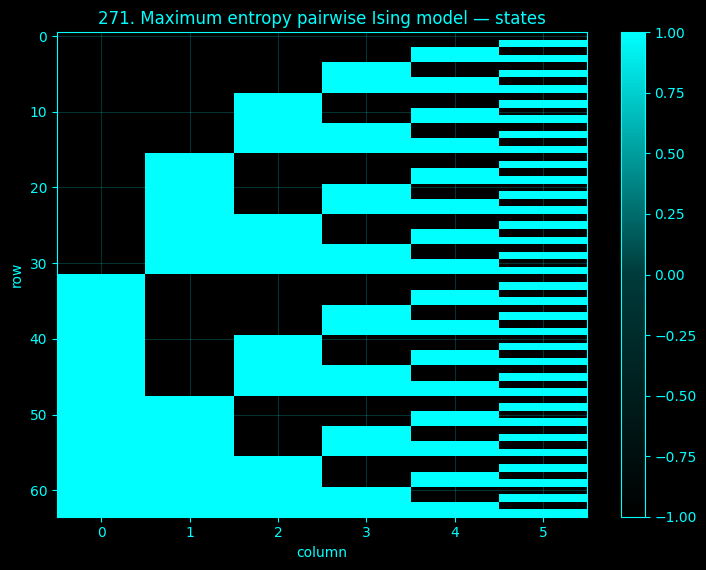

In [249]:
# =======================================================
# 271. Maximum entropy pairwise Ising model
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: The pairwise maximum-entropy Ising model is
# $P(s)=Z^{-1}\exp(\sum_ih_is_i+\sum_{i<j}J_{ij}s_is_j)$. For six binarized channels all $2^6$ states
# are enumerated and the convex log-likelihood is optimized to match empirical first and pairwise
# moments.
# =======================================================
def _entropy_method_271():
    y = _ent_y
    sym = _symbolize(y, 4)
    B = _binary_states(nch=6)
    states, p, th, obj, ok = _ising_fit(B[::max(1, len(B) // 1200)])
    _ent_print_args = ['pairwise Ising maxent fitted=', ok, 'model entropy=', _H(p), 'states=', len(states), 'parameters=', len(th)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_271()
_ent_auto_plot(271, 'Maximum entropy pairwise Ising model', _ent_method_ns, ['y', 'sym', 'B', '_ent_print_args', 'states', 'p', 'th', 'obj', 'ok'])


### 272. Maximum entropy channel distribution

With no constraints beyond normalization over $N$ channels, Shannon entropy is maximized by the uniform categorical distribution $p_i=1/N$, giving $H_{max}=\ln N$. The cell contrasts this mathematical maximum with the empirical normalized channel-power distribution.

**Implementation.** The formulas are evaluated on the same EEG segment. Finite-data proxies are labelled as such, and computational budgets follow `full / balanced / fast / ultra`.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


unconstrained maximum-entropy channel distribution H=ln N= 3.4657359027997265 empirical power-distribution H= 3.4657359027997265


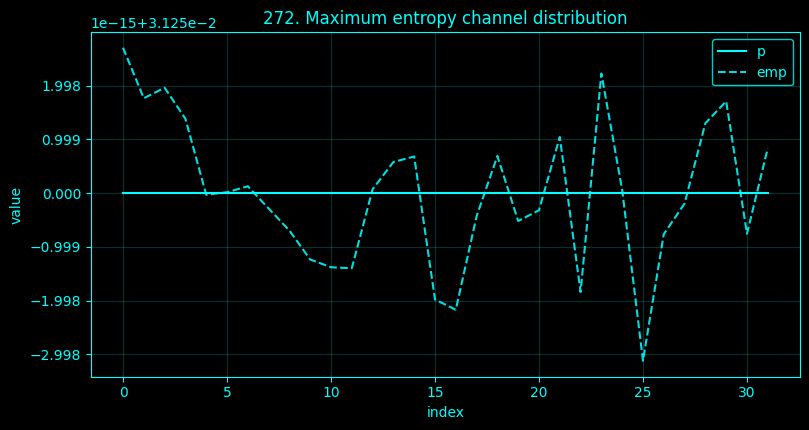

In [250]:
# =======================================================
# 272. Maximum entropy channel distribution
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: With no constraints beyond normalization over $N$ channels, Shannon entropy is
# maximized by the uniform categorical distribution $p_i=1/N$, giving $H_{max}=\ln N$. The cell
# contrasts this mathematical maximum with the empirical normalized channel-power distribution.
# =======================================================
def _entropy_method_272():
    y = _ent_y
    sym = _symbolize(y, 4)
    B = _binary_states(nch=6)
    N = _ent_x.shape[1]
    p = np.ones(N) / N
    emp = _safe_prob(np.var(_ent_x, axis=0))
    _ent_print_args = ['unconstrained maximum-entropy channel distribution H=ln N=', _H(p), 'empirical power-distribution H=', _H(emp)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_272()
_ent_auto_plot(272, 'Maximum entropy channel distribution', _ent_method_ns, ['y', 'sym', 'B', 'N', 'p', 'emp', '_ent_print_args'])


### 273. Entropy-regularized state model

Entropy-regularized state assignment minimizes expected state energy plus a negative-entropy penalty. For squared-distance energy $E_{tk}$ and temperature $T$, the optimum is the Gibbs/softmax law $p_{tk}\propto e^{-E_{tk}/T}$.

**Implementation.** The formulas are evaluated on the same EEG segment. Finite-data proxies are labelled as such, and computational budgets follow `full / balanced / fast / ultra`.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The proportionality symbol means the two quantities are expected to follow the same scaling law up to a multiplicative constant.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


entropy-regularized soft-state occupancy= [0.2370719  0.09618101 0.33010787 0.33663923] occupancy entropy= 1.2988335527220216 mean assignment entropy= 0.3271944999985546


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


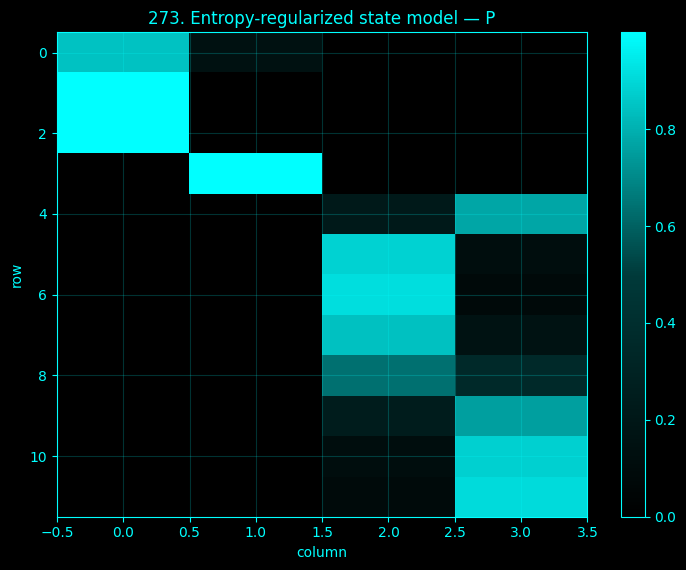

In [251]:
# =======================================================
# 273. Entropy-regularized state model
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Entropy-regularized state assignment minimizes expected state energy plus a negative-
# entropy penalty. For squared-distance energy $E_{tk}$ and temperature $T$, the optimum is the
# Gibbs/softmax law $p_{tk}\propto e^{-E_{tk}/T}$.
# =======================================================
def _entropy_method_273():
    y = _ent_y
    sym = _symbolize(y, 4)
    B = _binary_states(nch=6)
    starts, WF = _window_entropy_features()
    Z, C, E, P = _soft_state_model(WF, 4, tau=0.7)
    occ = P.mean(0)
    _ent_print_args = ['entropy-regularized soft-state occupancy=', occ, 'occupancy entropy=', _H(occ), 'mean assignment entropy=', float(np.mean(-np.sum(P * np.log(P + ENT_EPS), axis=1)))]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_273()
_ent_auto_plot(273, 'Entropy-regularized state model', _ent_method_ns, ['y', 'sym', 'B', 'occ', '_ent_print_args', 'starts', 'WF', 'Z', 'C', 'E', 'P'])


### 274. Free-energy entropy decomposition

For the soft state model, internal energy is $U_t=\sum_kp_{tk}E_{tk}$, entropy $S_t=-\sum_kp_{tk}\ln p_{tk}$ and free energy is $F_t=U_t-TS_t$. The cell verifies this decomposition numerically.

**Implementation.** The formulas are evaluated on the same EEG segment. Finite-data proxies are labelled as such, and computational budgets follow `full / balanced / fast / ultra`.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


{'mean_internal_energy': 0.6982338533013568, 'T_times_entropy': 0.2290361499989882, 'mean_free_energy': 0.46919770330236843, 'identity_residual': 0.0}


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


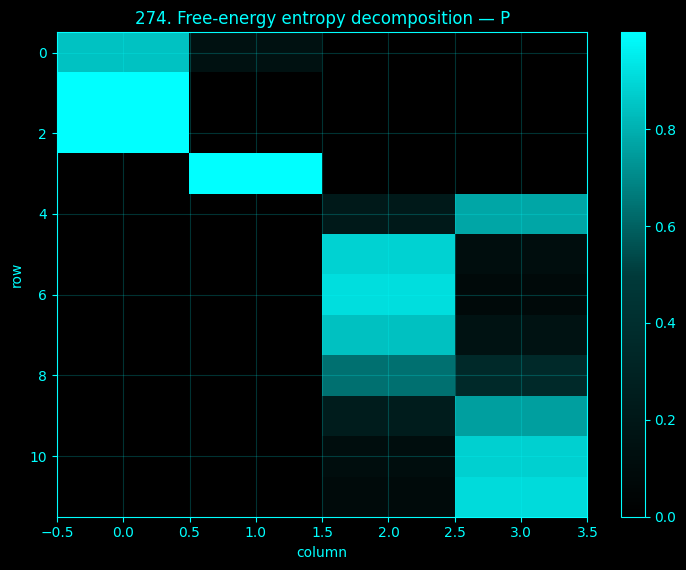

In [252]:
# =======================================================
# 274. Free-energy entropy decomposition
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: For the soft state model, internal energy is $U_t=\sum_kp_{tk}E_{tk}$, entropy
# $S_t=-\sum_kp_{tk}\ln p_{tk}$ and free energy is $F_t=U_t-TS_t$. The cell verifies this
# decomposition numerically.
# =======================================================
def _entropy_method_274():
    y = _ent_y
    sym = _symbolize(y, 4)
    B = _binary_states(nch=6)
    starts, WF = _window_entropy_features()
    Z, C, E, P = _soft_state_model(WF, 4, tau=0.7)
    T = 0.7
    U = np.sum(P * E, axis=1)
    S = -np.sum(P * np.log(P + ENT_EPS), axis=1)
    F = U - T * S
    _ent_print_args = [{'mean_internal_energy': float(np.mean(U)), 'T_times_entropy': float(T * np.mean(S)), 'mean_free_energy': float(np.mean(F)), 'identity_residual': float(np.mean(F - (U - T * S)))}]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_274()
_ent_auto_plot(274, 'Free-energy entropy decomposition', _ent_method_ns, ['y', 'sym', 'B', 'T', 'U', 'S', 'F', '_ent_print_args', 'starts', 'WF', 'Z', 'C', 'E', 'P'])


### 275. Energy-entropy phase plot

The energy–entropy phase plot places each analysis window at $(U_t,S_t)$ from the entropy-regularized state model, showing whether low-energy state fits coincide with concentrated or diffuse state assignments.

**Implementation.** The formulas are evaluated on the same EEG segment. Finite-data proxies are labelled as such, and computational budgets follow `full / balanced / fast / ultra`.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


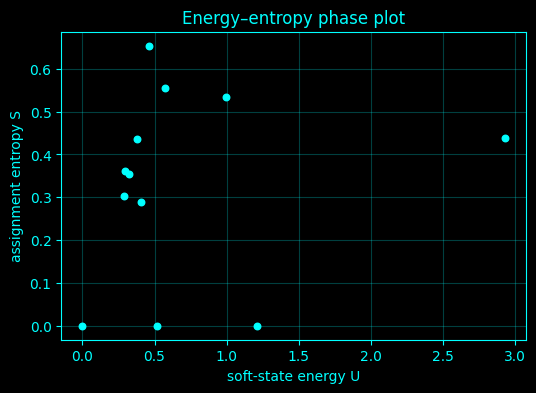

,time_s,energy,entropy
0,0.000,2.930832,4.375600e-01
1,1.360,1.212971,6.965343e-07
2,2.720,0.514961,6.908936e-05
3,4.088,0.000243,3.808089e-04
4,5.448,0.993203,5.351806e-01
5,6.816,0.323508,3.537984e-01
6,8.176,0.409021,2.886591e-01
7,9.544,0.379906,4.363736e-01
8,10.904,0.458588,6.539409e-01
9,12.272,0.573958,5.552514e-01


In [253]:
# =======================================================
# 275. Energy-entropy phase plot
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: The energy–entropy phase plot places each analysis window at $(U_t,S_t)$ from the
# entropy-regularized state model, showing whether low-energy state fits coincide with concentrated or
# diffuse state assignments.
# =======================================================
def _entropy_method_275():
    y = _ent_y
    sym = _symbolize(y, 4)
    B = _binary_states(nch=6)
    starts, WF = _window_entropy_features()
    Z, C, E, P = _soft_state_model(WF, 4, tau=0.7)
    T = 0.7
    U = np.sum(P * E, axis=1)
    S = -np.sum(P * np.log(P + ENT_EPS), axis=1)
    plt.figure(figsize=(6, 4))
    plt.scatter(U, S, s=22)
    plt.xlabel('soft-state energy U')
    plt.ylabel('assignment entropy S')
    plt.title('Energy–entropy phase plot')
    plt.grid(alpha=0.25)
    plt.show()
    plt.close()
    _ent_display_result = pd.DataFrame({'time_s': starts / _ent_fs, 'energy': U, 'entropy': S})
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_275()


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and role — density-operator information helpers for methods 276–287</h3>
<p>This foundation constructs finite-dimensional positive trace-one matrices from classical EEG covariance or analytic feature states and applies quantum-information mathematics such as \(S(\rho)=-\mathrm{Tr}(\rho\log\rho)\), quantum relative entropy \(D(\rho\|\sigma)=\mathrm{Tr}[\rho(\log\rho-\log\sigma)]\), and reduced-state/Schmidt entropies. These are mathematical analogues applied to EEG-derived operators, not evidence of physical quantum states or entanglement in brain tissue.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ρ (rho) is often used for a correlation, density, or similarity measure; its role is determined by the equation's definition.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


In [254]:
# =======================================================
# Shared primitives only; numbered cells below contain the method-specific mathematics.
# SHARED NUMERICAL PRIMITIVES — methods 276–287
# Quantum-information mathematics applied to explicitly defined EEG-derived
# density-operator analogues; no claim of physical quantum brain states.
# =======================================================
def _density_cov(X):
    X=np.asarray(X,float);C=np.cov(X,rowvar=False);C=(C+C.T)/2;w,V=np.linalg.eigh(C);w=np.clip(w,0,None);C=(V*w)@V.T;tr=np.trace(C);return C/(tr+ENT_EPS)

def _qentropy(rho):
    rho=np.asarray(rho,complex);w=np.linalg.eigvalsh((rho+rho.conj().T)/2).real;w=np.clip(w,0,None);w=w/(w.sum()+ENT_EPS);return _H(w),w

def _qrel(rho,sigma,floor=1e-10):
    rho=np.asarray(rho,complex);sigma=np.asarray(sigma,complex);wr,Ur=np.linalg.eigh((rho+rho.conj().T)/2);ws,Us=np.linalg.eigh((sigma+sigma.conj().T)/2);wr=np.clip(wr,0,None);wr=wr/(wr.sum()+ENT_EPS);ws=np.clip(ws,floor,None);ws=ws/ws.sum();lr=Ur@np.diag(np.log(np.clip(wr,floor,None)))@Ur.conj().T;ls=Us@np.diag(np.log(ws))@Us.conj().T;return float(np.real(np.trace(rho@(lr-ls))))

def _analytic_state(nch):
    nch=min(int(nch),_ent_x.shape[1]);Z=signal.hilbert(_ent_x[:,:nch],axis=0);idx=int(np.argmax(np.sum(np.abs(Z)**2,axis=1)));psi=Z[idx].astype(complex);return psi/(np.linalg.norm(psi)+ENT_EPS),idx

def _pure_reduced(psi,dA,dB):
    psi=np.asarray(psi,complex).ravel();assert len(psi)==dA*dB;M=psi.reshape(dA,dB);rhoA=M@M.conj().T;rhoB=M.conj().T@M;rhoA/=np.trace(rhoA)+ENT_EPS;rhoB/=np.trace(rhoB)+ENT_EPS;return rhoA,rhoB

def _partial_traces(rho,dA,dB):
    R=np.asarray(rho,complex).reshape(dA,dB,dA,dB);rhoA=np.einsum('abcb->ac',R);rhoB=np.einsum('abac->bc',R);return rhoA,rhoB

def _bitcode(B):
    B=np.asarray(B,int);return np.sum(B*(1<<np.arange(B.shape[1])),axis=1).astype(int)

def _rho_windows(nch=8):
    nch=min(nch,_ent_x.shape[1]);W=max(80,int(3*_ent_fs));starts=np.linspace(0,max(0,len(_ent_x)-W),_ENT_SPEED['windows']).astype(int);return starts,[_density_cov(_ent_x[s:s+W,:nch]) for s in starts]

def _osee(rho,dA=2,dB=2):
    R=np.asarray(rho,complex).reshape(dA,dB,dA,dB).transpose(0,2,1,3).reshape(dA*dA,dB*dB);s=np.linalg.svd(R,compute_uv=False);p=_safe_prob(s*s);return _H(p),p

def _discord_Z_proxy(rho):
    rho=np.asarray(rho,complex);rhoA,rhoB=_partial_traces(rho,2,2);SA=_qentropy(rhoA)[0];SB=_qentropy(rhoB)[0];SAB=_qentropy(rho)[0];I=SA+SB-SAB;R=rho.reshape(2,2,2,2);cond=0.
    for b in range(2):
        A=R[:,b,:,b];pb=float(np.real(np.trace(A)))
        if pb>ENT_EPS:cond+=pb*_qentropy(A/pb)[0]
    Jz=SA-cond;return float(I),float(Jz),float(max(0,I-Jz))


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Execution router — entropy methods 276–287</h3>
<p>This dispatcher selects the requested density-operator information calculation. It shares the same PSD/trace-one construction and numerical eigenspectrum safeguards across methods but introduces no new quantum-information definition of its own.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The density-matrix formalism represents a state by a positive semidefinite matrix with unit trace. Diagonal elements can be read as basis-dependent weights, while off-diagonal elements encode coherence between basis states. In an EEG application this is a mathematical representation borrowed from quantum information; unless the notebook explicitly models quantum physical measurements, the quantities should be understood as signal-analysis constructs rather than evidence of microscopic quantum brain dynamics.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


**Explicit implementation note — methods 276–287.**  
The catalogue dispatcher has been removed. Each numbered method below now contains its own executable mathematics in that method's code cell. Only reusable numerical primitives and the shared black/cyan plotting utilities remain centralized.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


### 276. Quantum relative entropy

For density operators $\rho$ and $\sigma$, quantum relative entropy is $D(\rho\|\sigma)=\mathrm{Tr}[\rho(\log\rho-\log\sigma)]$, finite when the support of $\rho$ lies in that of $\sigma$. The cell uses trace-normalized EEG covariance matrices as explicit density-operator analogues and a tiny numerical eigenvalue floor for finite-sample stability.

**Implementation.** All quantum-information quantities are applied to explicitly defined EEG-derived mathematical states/operators. They are not presented as evidence that the measured EEG is a physical quantum system.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ρ (rho) is often used for a correlation, density, or similarity measure; its role is determined by the equation's definition.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


quantum relative entropy D(rho1||rho2)= 0.7076606225059163 for covariance-density analogues


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


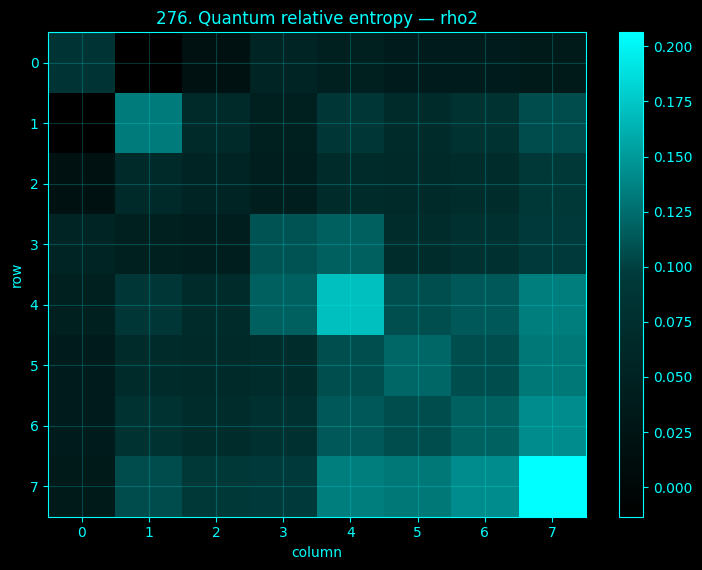

In [255]:
# =======================================================
# 276. Quantum relative entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: For density operators $\rho$ and $\sigma$, quantum relative entropy is
# $D(\rho\|\sigma)=\mathrm{Tr}[\rho(\log\rho-\log\sigma)]$, finite when the support of $\rho$ lies in
# that of $\sigma$. The cell uses trace-normalized EEG covariance matrices as explicit density-
# operator analogues and a tiny numerical eigenvalue floor for finite-sample stability.
# =======================================================
def _entropy_method_276():
    X = _ent_x
    nch = min(8, X.shape[1])
    mid = len(X) // 2
    rho1 = _density_cov(X[:mid, :nch])
    rho2 = _density_cov(X[mid:, :nch])
    _ent_print_args = ['quantum relative entropy D(rho1||rho2)=', _qrel(rho1, rho2), 'for covariance-density analogues']
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_276()
_ent_auto_plot(276, 'Quantum relative entropy', _ent_method_ns, ['X', 'nch', 'mid', 'rho1', 'rho2', '_ent_print_args'])


### 277. Quantum Jensen-Shannon divergence

Quantum Jensen–Shannon divergence is $J_Q(\rho,\sigma)=S[(\rho+\sigma)/2]-\tfrac12S(\rho)-\tfrac12S(\sigma)$ with von Neumann entropy $S(\rho)=-\mathrm{Tr}(\rho\log\rho)$. It is evaluated between covariance-density analogues from two time halves.

**Implementation.** All quantum-information quantities are applied to explicitly defined EEG-derived mathematical states/operators. They are not presented as evidence that the measured EEG is a physical quantum system.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ρ (rho) is often used for a correlation, density, or similarity measure; its role is determined by the equation's definition.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


quantum Jensen-Shannon divergence= 0.13811127148402202


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


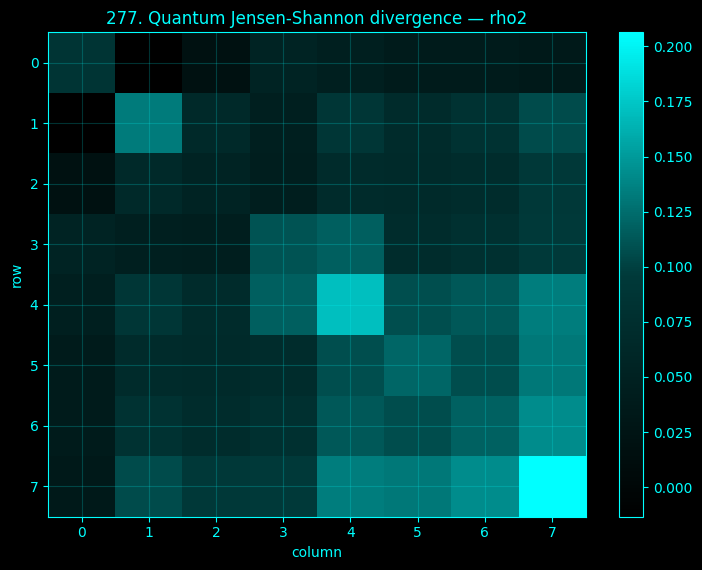

In [256]:
# =======================================================
# 277. Quantum Jensen-Shannon divergence
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Quantum Jensen–Shannon divergence is
# $J_Q(\rho,\sigma)=S[(\rho+\sigma)/2]-\tfrac12S(\rho)-\tfrac12S(\sigma)$ with von Neumann entropy
# $S(\rho)=-\mathrm{Tr}(\rho\log\rho)$. It is evaluated between covariance-density analogues from two
# time halves.
# =======================================================
def _entropy_method_277():
    X = _ent_x
    nch = min(8, X.shape[1])
    mid = len(X) // 2
    rho1 = _density_cov(X[:mid, :nch])
    rho2 = _density_cov(X[mid:, :nch])
    m = 0.5 * (rho1 + rho2)
    js = _qentropy(m)[0] - 0.5 * _qentropy(rho1)[0] - 0.5 * _qentropy(rho2)[0]
    _ent_print_args = ['quantum Jensen-Shannon divergence=', float(js)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_277()
_ent_auto_plot(277, 'Quantum Jensen-Shannon divergence', _ent_method_ns, ['X', 'nch', 'mid', 'rho1', 'rho2', 'm', 'js', '_ent_print_args'])


### 278. Entanglement entropy

A normalized four-channel complex analytic-state vector is interpreted mathematically as $|\psi\rangle\in\mathbb C^2\otimes\mathbb C^2$. For the pure state, entanglement entropy is $S(\rho_A)$ with $\rho_A=\mathrm{Tr}_B|\psi\rangle\langle\psi|$. This is a channel-space analogue, not physical neural quantum entanglement.

**Implementation.** All quantum-information quantities are applied to explicitly defined EEG-derived mathematical states/operators. They are not presented as evidence that the measured EEG is a physical quantum system.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The density-matrix formalism represents a state by a positive semidefinite matrix with unit trace. Diagonal elements can be read as basis-dependent weights, while off-diagonal elements encode coherence between basis states. In an EEG application this is a mathematical representation borrowed from quantum information; unless the notebook explicitly models quantum physical measurements, the quantities should be understood as signal-analysis constructs rather than evidence of microscopic quantum brain dynamics.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble. The symbol ρ (rho) is often used for a correlation, density, or similarity measure; its role is determined by the equation's definition.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


two-qubit-analogue pure-state entanglement entropy= 0.27681522168801886 sample= 505 (mathematical channel-space factorization only)


/tmp/ipykernel_122194/2362577716.py:543: ComplexWarning: Casting complex values to real discards the imaginary part
  arr = arr.astype(float)
/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


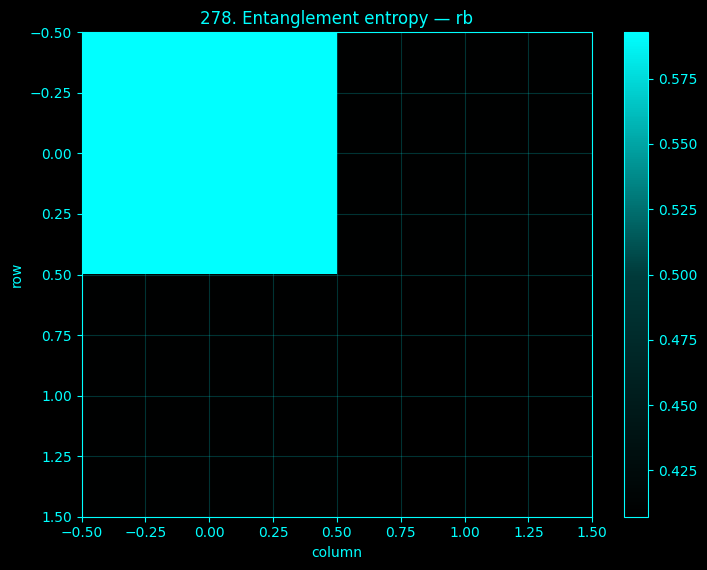

In [257]:
# =======================================================
# 278. Entanglement entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: A normalized four-channel complex analytic-state vector is interpreted mathematically
# as $|\psi\rangle\in\mathbb C^2\otimes\mathbb C^2$. For the pure state, entanglement entropy is
# $S(\rho_A)$ with $\rho_A=\mathrm{Tr}_B|\psi\rangle\langle\psi|$. This is a channel-space analogue,
# not physical neural quantum entanglement.
# =======================================================
def _entropy_method_278():
    X = _ent_x
    nch = min(8, X.shape[1])
    mid = len(X) // 2
    rho1 = _density_cov(X[:mid, :nch])
    rho2 = _density_cov(X[mid:, :nch])
    psi, idx = _analytic_state(4)
    ra, rb = _pure_reduced(psi, 2, 2)
    _ent_print_args = ['two-qubit-analogue pure-state entanglement entropy=', _qentropy(ra)[0], 'sample=', idx, '(mathematical channel-space factorization only)']
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_278()
_ent_auto_plot(278, 'Entanglement entropy', _ent_method_ns, ['X', 'nch', 'mid', 'rho1', 'rho2', '_ent_print_args', 'psi', 'idx', 'ra', 'rb'])


### 279. Bipartite entanglement entropy

For a chosen factorization $\mathbb C^{d_Ad_B}\cong\mathbb C^{d_A}\otimes\mathbb C^{d_B}$ of a normalized analytic channel vector, bipartite pure-state entanglement is the von Neumann entropy of either reduced density matrix. The factorization is an explicit mathematical construction.

**Implementation.** All quantum-information quantities are applied to explicitly defined EEG-derived mathematical states/operators. They are not presented as evidence that the measured EEG is a physical quantum system.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The density-matrix formalism represents a state by a positive semidefinite matrix with unit trace. Diagonal elements can be read as basis-dependent weights, while off-diagonal elements encode coherence between basis states. In an EEG application this is a mathematical representation borrowed from quantum information; unless the notebook explicitly models quantum physical measurements, the quantities should be understood as signal-analysis constructs rather than evidence of microscopic quantum brain dynamics.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


bipartite pure-state analogue entanglement entropy= 0.18921893372965337 Schmidt rank <= 4


/tmp/ipykernel_122194/2362577716.py:543: ComplexWarning: Casting complex values to real discards the imaginary part
  arr = arr.astype(float)
/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


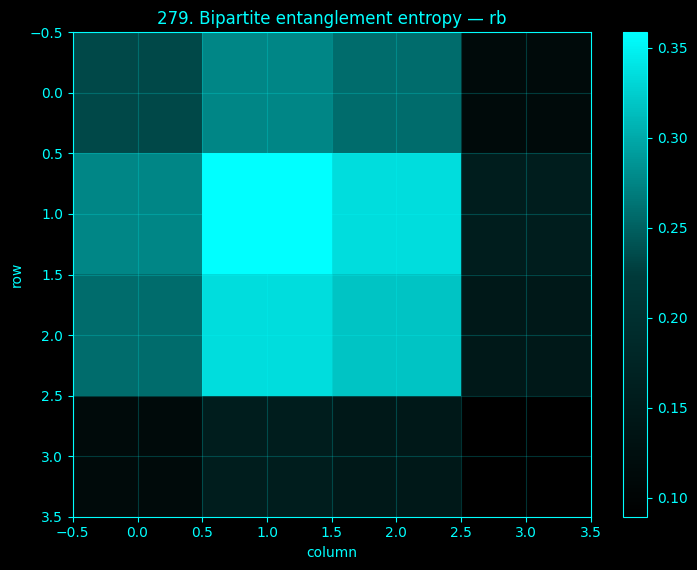

In [258]:
# =======================================================
# 279. Bipartite entanglement entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: For a chosen factorization $\mathbb C^{d_Ad_B}\cong\mathbb C^{d_A}\otimes\mathbb
# C^{d_B}$ of a normalized analytic channel vector, bipartite pure-state entanglement is the von
# Neumann entropy of either reduced density matrix. The factorization is an explicit mathematical
# construction.
# =======================================================
def _entropy_method_279():
    X = _ent_x
    nch = min(8, X.shape[1])
    mid = len(X) // 2
    rho1 = _density_cov(X[:mid, :nch])
    rho2 = _density_cov(X[mid:, :nch])
    psi, idx = _analytic_state(16 if X.shape[1] >= 16 else 4)
    if len(psi) >= 16:
        psi = psi[:16]
        psi /= np.linalg.norm(psi) + ENT_EPS
        ra, rb = _pure_reduced(psi, 4, 4)
    else:
        ra, rb = _pure_reduced(psi[:4] / (np.linalg.norm(psi[:4]) + ENT_EPS), 2, 2)
    _ent_print_args = ['bipartite pure-state analogue entanglement entropy=', _qentropy(ra)[0], 'Schmidt rank <=', len(ra)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_279()
_ent_auto_plot(279, 'Bipartite entanglement entropy', _ent_method_ns, ['X', 'nch', 'mid', 'rho1', 'rho2', '_ent_print_args', 'psi', 'idx', 'ra', 'rb'])


### 280. Mutual information across arbitrary channel bipartitions

For arbitrary channel groups $A$ and $B$, this cell uses classical mutual information $I(A;B)=H(A)+H(B)-H(A,B)$ after binary channel-state encoding. This avoids inventing a tensor-product quantum structure where none is physically specified.

**Implementation.** All quantum-information quantities are applied to explicitly defined EEG-derived mathematical states/operators. They are not presented as evidence that the measured EEG is a physical quantum system.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Mutual information measures how much knowing one variable reduces uncertainty about another. Unlike linear correlation, it can capture nonlinear statistical dependence. In delay-selection problems, mutual information between a signal and a delayed copy is examined as the delay changes; a local minimum is often used as a compromise between coordinates that are too redundant and coordinates that are almost unrelated. The estimate is sensitive to finite sample size and to how probability densities are estimated.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


classical mutual information across channel bipartition= 0.5654668188914318 nats


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


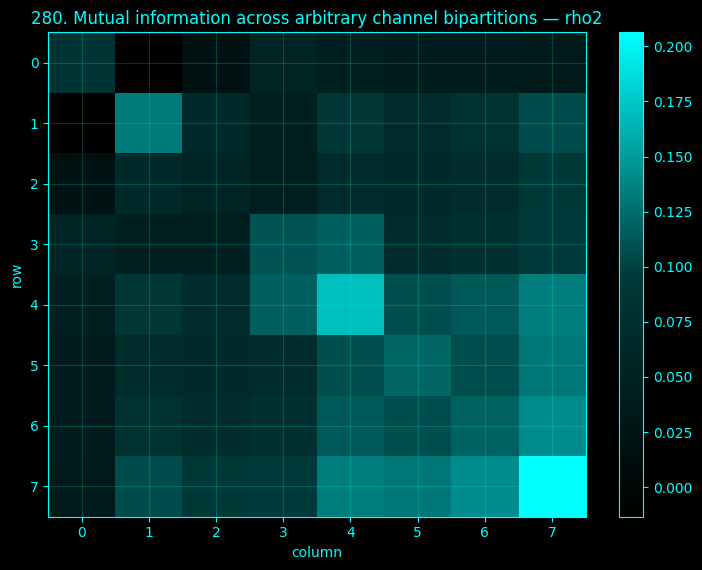

In [259]:
# =======================================================
# 280. Mutual information across arbitrary channel bipartitions
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: For arbitrary channel groups $A$ and $B$, this cell uses classical mutual information
# $I(A;B)=H(A)+H(B)-H(A,B)$ after binary channel-state encoding. This avoids inventing a tensor-
# product quantum structure where none is physically specified.
# =======================================================
def _entropy_method_280():
    X = _ent_x
    nch = min(8, X.shape[1])
    mid = len(X) // 2
    rho1 = _density_cov(X[:mid, :nch])
    rho2 = _density_cov(X[mid:, :nch])
    B = _binary_states(nch=min(8, X.shape[1]))
    k = B.shape[1] // 2
    a = _bitcode(B[:, :k])
    b = _bitcode(B[:, k:])
    _ent_print_args = ['classical mutual information across channel bipartition=', _MI(a, b), 'nats']
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_280()
_ent_auto_plot(280, 'Mutual information across arbitrary channel bipartitions', _ent_method_ns, ['X', 'nch', 'mid', 'rho1', 'rho2', 'B', 'k', 'a', 'b', '_ent_print_args'])


### 281. Tripartite information

Tripartite information is $I_3(A:B:C)=I(A:B)+I(A:C)-I(A:BC)$, equivalently a signed inclusion–exclusion combination of entropies. Negative values can indicate synergy-like dependence, but interpretation depends on the chosen coarse-grained variables.

**Implementation.** All quantum-information quantities are applied to explicitly defined EEG-derived mathematical states/operators. They are not presented as evidence that the measured EEG is a physical quantum system.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The density-matrix formalism represents a state by a positive semidefinite matrix with unit trace. Diagonal elements can be read as basis-dependent weights, while off-diagonal elements encode coherence between basis states. In an EEG application this is a mathematical representation borrowed from quantum information; unless the notebook explicitly models quantum physical measurements, the quantities should be understood as signal-analysis constructs rather than evidence of microscopic quantum brain dynamics.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


tripartite information I3(A:B:C)= 0.05010037188390637


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


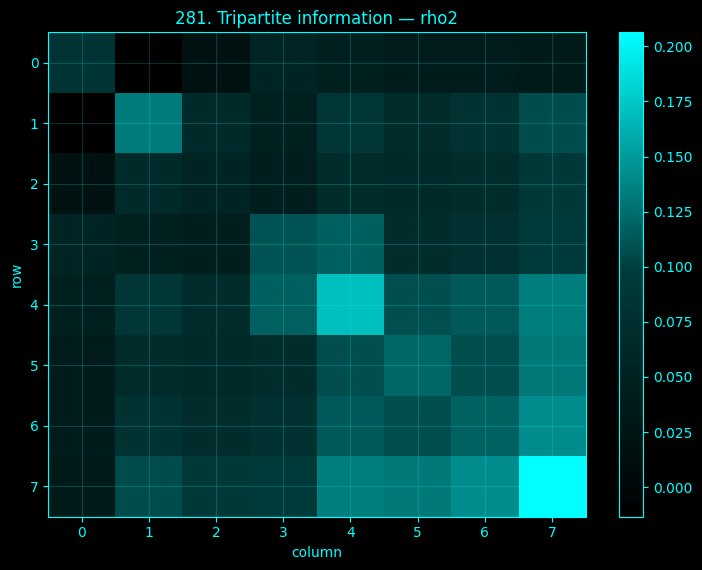

In [260]:
# =======================================================
# 281. Tripartite information
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Tripartite information is $I_3(A:B:C)=I(A:B)+I(A:C)-I(A:BC)$, equivalently a signed
# inclusion–exclusion combination of entropies. Negative values can indicate synergy-like dependence,
# but interpretation depends on the chosen coarse-grained variables.
# =======================================================
def _entropy_method_281():
    X = _ent_x
    nch = min(8, X.shape[1])
    mid = len(X) // 2
    rho1 = _density_cov(X[:mid, :nch])
    rho2 = _density_cov(X[mid:, :nch])
    B = _binary_states(nch=min(9, X.shape[1]))
    g = max(1, B.shape[1] // 3)
    a = _bitcode(B[:, :g])
    b = _bitcode(B[:, g:2 * g])
    c = _bitcode(B[:, 2 * g:3 * g])
    bc = np.array([u * 2 ** g + v for u, v in zip(b, c)])
    I3 = _MI(a, b) + _MI(a, c) - _MI(a, bc)
    _ent_print_args = ['tripartite information I3(A:B:C)=', I3]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_281()
_ent_auto_plot(281, 'Tripartite information', _ent_method_ns, ['X', 'nch', 'mid', 'rho1', 'rho2', 'B', 'g', 'a', 'b', 'c', 'bc', 'I3', '_ent_print_args', 'u', 'v'])


### 282. Operator-space entanglement entropy

Operator-space entanglement treats an operator on $\mathcal H_A\otimes\mathcal H_B$ as a vector in Hilbert–Schmidt space. After reshaping $\rho_{ab,a\prime b\prime}$ into matrix indices $(a,a\prime)$ and $(b,b\prime)$, squared normalized singular values $p_k$ define $S_{op}=-\sum_kp_k\ln p_k$.

**Implementation.** All quantum-information quantities are applied to explicitly defined EEG-derived mathematical states/operators. They are not presented as evidence that the measured EEG is a physical quantum system.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The density-matrix formalism represents a state by a positive semidefinite matrix with unit trace. Diagonal elements can be read as basis-dependent weights, while off-diagonal elements encode coherence between basis states. In an EEG application this is a mathematical representation borrowed from quantum information; unless the notebook explicitly models quantum physical measurements, the quantities should be understood as signal-analysis constructs rather than evidence of microscopic quantum brain dynamics.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


operator-space entanglement entropy= 0.42842358061205865 operator Schmidt probabilities= [0.8730114  0.11469088 0.00872765 0.00357008]


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


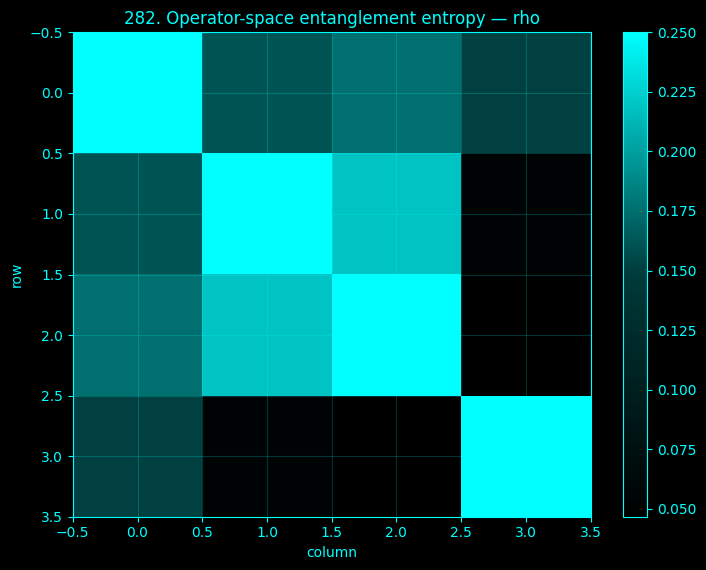

In [261]:
# =======================================================
# 282. Operator-space entanglement entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Operator-space entanglement treats an operator on $\mathcal H_A\otimes\mathcal H_B$ as
# a vector in Hilbert–Schmidt space. After reshaping $\rho_{ab,a\prime b\prime}$ into matrix indices
# $(a,a\prime)$ and $(b,b\prime)$, squared normalized singular values $p_k$ define
# $S_{op}=-\sum_kp_k\ln p_k$.
# =======================================================
def _entropy_method_282():
    X = _ent_x
    nch = min(8, X.shape[1])
    mid = len(X) // 2
    rho1 = _density_cov(X[:mid, :nch])
    rho2 = _density_cov(X[mid:, :nch])
    rho = _density_cov(X[:, :4])
    h, p = _osee(rho, 2, 2)
    _ent_print_args = ['operator-space entanglement entropy=', h, 'operator Schmidt probabilities=', p]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_282()
_ent_auto_plot(282, 'Operator-space entanglement entropy', _ent_method_ns, ['X', 'nch', 'mid', 'rho1', 'rho2', 'rho', '_ent_print_args', 'h', 'p'])


### 283. Holevo information

For an ensemble $\{p_k,\rho_k\}$, Holevo information is $\chi=S(\bar\rho)-\sum_kp_kS(\rho_k)$ with $\bar\rho=\sum_kp_k\rho_k$. Equal-prior window covariance-density analogues form the ensemble here.

**Implementation.** All quantum-information quantities are applied to explicitly defined EEG-derived mathematical states/operators. They are not presented as evidence that the measured EEG is a physical quantum system.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ρ (rho) is often used for a correlation, density, or similarity measure; its role is determined by the equation's definition.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Holevo information of equal-prior window density ensemble= 0.18709288183821393


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


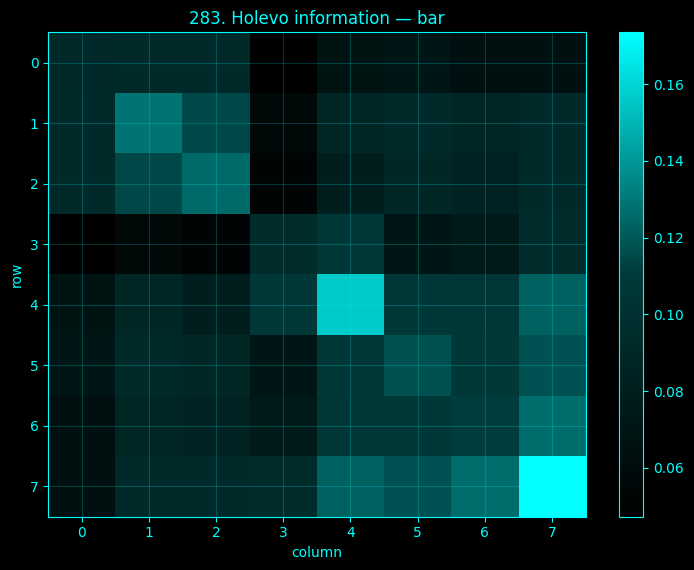

In [262]:
# =======================================================
# 283. Holevo information
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: For an ensemble $\{p_k,\rho_k\}$, Holevo information is
# $\chi=S(\bar\rho)-\sum_kp_kS(\rho_k)$ with $\bar\rho=\sum_kp_k\rho_k$. Equal-prior window
# covariance-density analogues form the ensemble here.
# =======================================================
def _entropy_method_283():
    X = _ent_x
    nch = min(8, X.shape[1])
    mid = len(X) // 2
    rho1 = _density_cov(X[:mid, :nch])
    rho2 = _density_cov(X[mid:, :nch])
    starts, rhos = _rho_windows(8)
    p = np.ones(len(rhos)) / max(1, len(rhos))
    bar = sum((w * r for w, r in zip(p, rhos)))
    chi = _qentropy(bar)[0] - sum((w * _qentropy(r)[0] for w, r in zip(p, rhos)))
    _ent_print_args = ['Holevo information of equal-prior window density ensemble=', float(chi)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_283()
_ent_auto_plot(283, 'Holevo information', _ent_method_ns, ['X', 'nch', 'mid', 'rho1', 'rho2', 'p', 'bar', 'chi', '_ent_print_args', 'starts', 'rhos', 'w', 'r'])


### 284. Quantum discord proxy

Quantum discord is $D=I-J_{max}$, where $J_{max}$ maximizes measurement-induced classical correlation over measurements. Full optimization is not attempted. The cell computes $I-J_Z$ for a fixed computational-basis projective measurement on subsystem B; because $J_Z\le J_{max}$ this is a basis-dependent upper proxy, not exact discord.

**Implementation.** All quantum-information quantities are applied to explicitly defined EEG-derived mathematical states/operators. They are not presented as evidence that the measured EEG is a physical quantum system.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The density-matrix formalism represents a state by a positive semidefinite matrix with unit trace. Diagonal elements can be read as basis-dependent weights, while off-diagonal elements encode coherence between basis states. In an EEG application this is a mathematical representation borrowed from quantum information; unless the notebook explicitly models quantum physical measurements, the quantities should be understood as signal-analysis constructs rather than evidence of microscopic quantum brain dynamics.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


{'quantum_mutual_information': 0.3232769365205981, 'classical_correlation_in_computational_basis': 0.038810041560688235, 'basis_dependent_discord_upper_proxy': 0.28446689495990984}


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


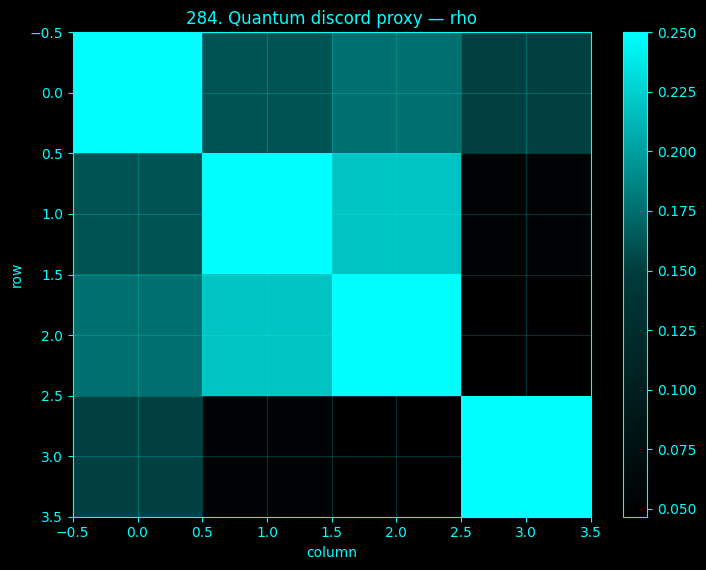

In [263]:
# =======================================================
# 284. Quantum discord proxy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Quantum discord is $D=I-J_{max}$, where $J_{max}$ maximizes measurement-induced
# classical correlation over measurements. Full optimization is not attempted. The cell computes
# $I-J_Z$ for a fixed computational-basis projective measurement on subsystem B; because $J_Z\le
# J_{max}$ this is a basis-dependent upper proxy, not exact discord.
# =======================================================
def _entropy_method_284():
    X = _ent_x
    nch = min(8, X.shape[1])
    mid = len(X) // 2
    rho1 = _density_cov(X[:mid, :nch])
    rho2 = _density_cov(X[mid:, :nch])
    rho = _density_cov(X[:, :4])
    I, Jz, Dz = _discord_Z_proxy(rho)
    _ent_print_args = [{'quantum_mutual_information': I, 'classical_correlation_in_computational_basis': Jz, 'basis_dependent_discord_upper_proxy': Dz}]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_284()
_ent_auto_plot(284, 'Quantum discord proxy', _ent_method_ns, ['X', 'nch', 'mid', 'rho1', 'rho2', 'rho', '_ent_print_args', 'I', 'Jz', 'Dz'])


### 285. Density-matrix entropy-rate trajectory

Each window produces a covariance-density operator $\rho_t$ and von Neumann entropy $S_t$. The displayed “entropy-rate trajectory” is the finite difference $dS_t/dt$ of this density-matrix entropy trajectory; it is not the stationary Shannon entropy rate of a stochastic process.

**Implementation.** All quantum-information quantities are applied to explicitly defined EEG-derived mathematical states/operators. They are not presented as evidence that the measured EEG is a physical quantum system.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ρ (rho) is often used for a correlation, density, or similarity measure; its role is determined by the equation's definition.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


,time_s,von_Neumann_entropy,dS_dt
0,0.000,0.632355,-0.165570
1,1.360,0.407181,-0.023054
2,2.720,0.569649,0.160236
3,4.088,0.843022,0.142513
4,5.448,0.957284,-0.052041
5,6.816,0.701470,-0.092350
6,8.176,0.706093,-0.000213
7,9.544,0.700891,-0.018721
8,10.904,0.655171,0.008150
9,12.272,0.723060,0.065704


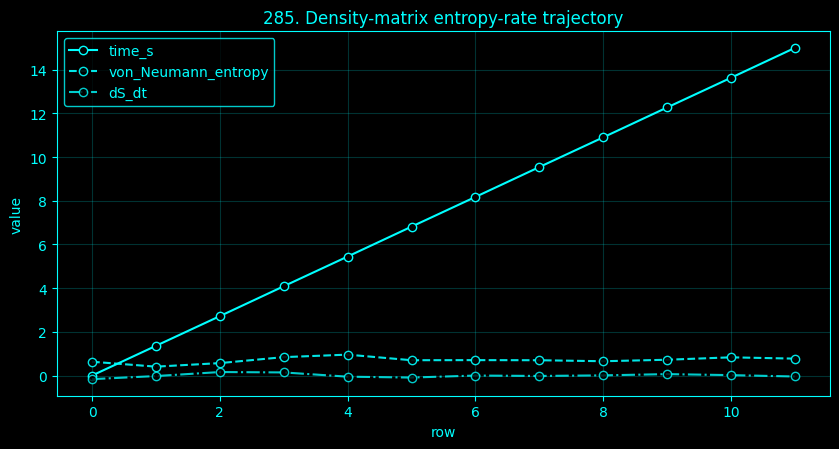

In [264]:
# =======================================================
# 285. Density-matrix entropy-rate trajectory
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Each window produces a covariance-density operator $\rho_t$ and von Neumann entropy
# $S_t$. The displayed “entropy-rate trajectory” is the finite difference $dS_t/dt$ of this density-
# matrix entropy trajectory; it is not the stationary Shannon entropy rate of a stochastic process.
# =======================================================
def _entropy_method_285():
    X = _ent_x
    nch = min(8, X.shape[1])
    mid = len(X) // 2
    rho1 = _density_cov(X[:mid, :nch])
    rho2 = _density_cov(X[mid:, :nch])
    starts, rhos = _rho_windows(8)
    S = np.array([_qentropy(r)[0] for r in rhos])
    dt = np.median(np.diff(starts)) / _ent_fs if len(starts) > 1 else 1.0
    rate = np.gradient(S, dt) if len(S) > 1 else np.array([0.0])
    _ent_display_result = pd.DataFrame({'time_s': starts / _ent_fs, 'von_Neumann_entropy': S, 'dS_dt': rate})
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_285()
_ent_auto_plot(285, 'Density-matrix entropy-rate trajectory', _ent_method_ns, ['X', 'nch', 'mid', 'rho1', 'rho2', 'S', 'dt', 'rate', '_ent_display_result', 'starts', 'rhos', 'r'])


### 286. Spectral participation entropy across Hamiltonian modes

The functional-connectivity graph Laplacian is used as an explicit Hamiltonian analogue $H=L$. For covariance-density state $\rho$, modal occupation is $p_k=\langle v_k|\rho|v_k\rangle$ in the eigenbasis of $H$. Spectral participation entropy is $-\sum_kp_k\ln p_k$.

**Implementation.** All quantum-information quantities are applied to explicitly defined EEG-derived mathematical states/operators. They are not presented as evidence that the measured EEG is a physical quantum system.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


spectral participation entropy across graph-Laplacian Hamiltonian modes= 1.6984558885716425 effective modes= 5.465501529355819


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


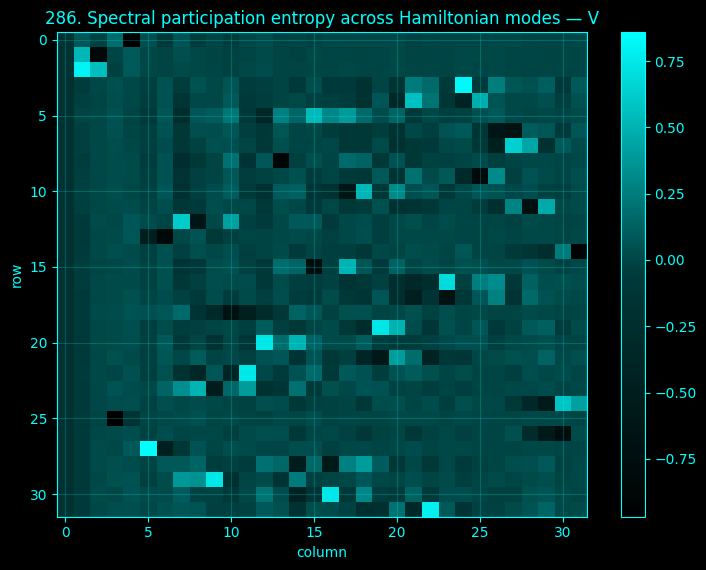

In [265]:
# =======================================================
# 286. Spectral participation entropy across Hamiltonian modes
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: The functional-connectivity graph Laplacian is used as an explicit Hamiltonian analogue
# $H=L$. For covariance-density state $\rho$, modal occupation is $p_k=\langle v_k|\rho|v_k\rangle$ in
# the eigenbasis of $H$. Spectral participation entropy is $-\sum_kp_k\ln p_k$.
# =======================================================
def _entropy_method_286():
    X = _ent_x
    nch = min(8, X.shape[1])
    mid = len(X) // 2
    rho1 = _density_cov(X[:mid, :nch])
    rho2 = _density_cov(X[mid:, :nch])
    _, W, A = _corr_graph(X, 0.0)
    L = np.diag(W.sum(1)) - W
    lam, V = np.linalg.eigh((L + L.T) / 2)
    rho = _density_cov(X)
    p = np.real(np.diag(V.conj().T @ rho @ V))
    p = _safe_prob(p)
    _ent_print_args = ['spectral participation entropy across graph-Laplacian Hamiltonian modes=', _H(p), 'effective modes=', np.exp(_H(p))]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_286()
_ent_auto_plot(286, 'Spectral participation entropy across Hamiltonian modes', _ent_method_ns, ['X', 'nch', 'mid', 'rho1', 'rho2', 'L', 'rho', 'p', '_ent_print_args', '_', 'W', 'A', 'lam', 'V'])


### 287. Entanglement spectrum entropy

For a pure bipartite state with Schmidt singular values $s_k$, entanglement-spectrum probabilities are $p_k=s_k^2/\sum_js_j^2$. Their Shannon entropy $-\sum_kp_k\ln p_k$ equals pure-state entanglement entropy for the chosen factorization.

**Implementation.** All quantum-information quantities are applied to explicitly defined EEG-derived mathematical states/operators. They are not presented as evidence that the measured EEG is a physical quantum system.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


entanglement-spectrum probabilities= [9.60590863e-01 3.08036154e-02 7.88600952e-03 7.19512130e-04] spectrum entropy= 0.18921893372884255


/tmp/ipykernel_122194/2362577716.py:543: ComplexWarning: Casting complex values to real discards the imaginary part
  arr = arr.astype(float)
/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


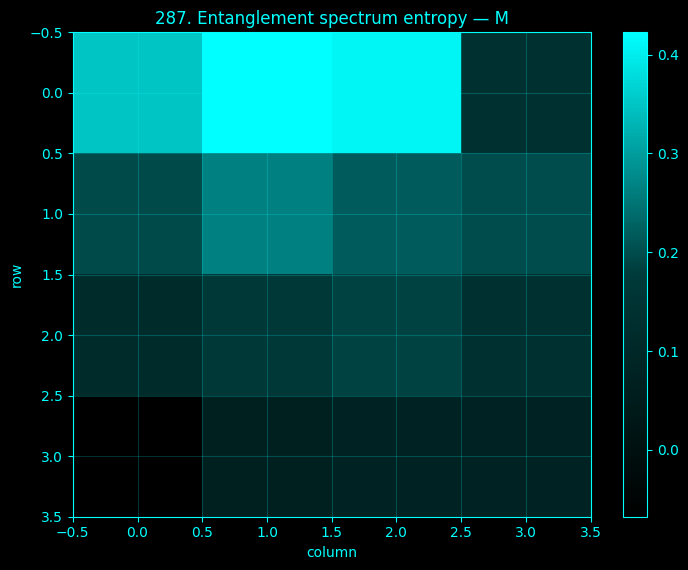

In [266]:
# =======================================================
# 287. Entanglement spectrum entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: For a pure bipartite state with Schmidt singular values $s_k$, entanglement-spectrum
# probabilities are $p_k=s_k^2/\sum_js_j^2$. Their Shannon entropy $-\sum_kp_k\ln p_k$ equals pure-
# state entanglement entropy for the chosen factorization.
# =======================================================
def _entropy_method_287():
    X = _ent_x
    nch = min(8, X.shape[1])
    mid = len(X) // 2
    rho1 = _density_cov(X[:mid, :nch])
    rho2 = _density_cov(X[mid:, :nch])
    psi, idx = _analytic_state(16 if X.shape[1] >= 16 else 4)
    if len(psi) >= 16:
        dA = dB = 4
        psi = psi[:16] / (np.linalg.norm(psi[:16]) + ENT_EPS)
    else:
        dA = dB = 2
        psi = psi[:4] / (np.linalg.norm(psi[:4]) + ENT_EPS)
    M = psi.reshape(dA, dB)
    s = np.linalg.svd(M, compute_uv=False)
    p = _safe_prob(s * s)
    _ent_print_args = ['entanglement-spectrum probabilities=', p, 'spectrum entropy=', _H(p)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_287()
_ent_auto_plot(287, 'Entanglement spectrum entropy', _ent_method_ns, ['X', 'nch', 'mid', 'rho1', 'rho2', 'M', 's', 'p', '_ent_print_args', 'psi', 'idx', 'dA', 'dB'])
